# 🌳 Bacia do Rio Xingu · 35 anos de clima diário (1990–2024)

    A bacia do Xingu nasce em Mato Grosso, na transição com o Cerrado, e deságua no Amazonas, no
Pará, depois de atravessar quase 14 graus de latitude. É um corredor com o maior mosaico contínuo de Terras
Indígenas e Unidades de Conservação da Amazônia e, ao mesmo tempo, com frentes antigas e
recentes de desmatamento nas bordas. Esse gradiente faz dela um laboratório natural para a
pergunta do TCC: **como a dinâmica climática diária se comporta ao longo de uma paisagem que
vai da floresta úmida às bordas do Cerrado e do protegido ao perturbado?**

    Neste caderno vamos **conhecer os dados antes de pedir qualquer coisa a eles**: onde estamos,
    de onde vêm os números, como é o ano típico, como o clima muda no espaço e nos 35 anos,
    quais foram os extremos e, por fim, um primeiro olhar "dinâmico", a ponte para a Teoria do Caos.

    | | Roteiro |
    |---|---|
    | 🗺️ | 1. Onde estamos? |
    | 🛰️ | 2. De onde vêm estes números? |
    | 📈 | 3. Do cubo de dados à série da região |
    | 🗓️ | 4. O ritmo do ano |
    | 🧭 | 5. A geografia do clima |
    | ☔ | 6. Duas estações, dois mapas |
    | ⏳ | 7. 35 anos: o que mudou? |
    | 🧩 | 8. Onde mudou mais? |
    | 🔥 | 9. Anomalias mês a mês e extremos |
    | 🧪 | 10. Arquivo 1990–2000 × janela científica 2001–2024 |
    | 🌀 | 11. Uma ponte para o caos: o espaço de fases |
    | ✅ | 12. Em resumo |

    > **Como ler:** tudo aqui é **descritivo**. Tendências e contrastes não são atribuídos a
    > desmatamento, fogo ou mudança climática global: isso exige as bases de perturbação e o
    > desenho comparativo do estudo. O caderno lê apenas arquivos locais e **não faz downloads**.

In [1]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display

from amazon_chaos.config import load_config
from amazon_chaos.io.era5_monthly import job_directory, plan_edh_requests
from amazon_chaos.nonlinear.embedding import delay_embedding
from amazon_chaos.nonlinear.surrogates import phase_randomized_surrogate
from amazon_chaos.regional import anomalies, region_cells, regional_frame, summarize, theil_sen
from amazon_chaos.viz import COLORS, LABELS, MONTHS, map_cells, save, show_md, style

%matplotlib inline
style()
ROOT = Path.cwd()
assert (ROOT / 'configs/xingu_1990_2024.yaml').exists(), 'Abra o kernel na raiz do projeto TCC.'
CFG = load_config(ROOT / 'configs/xingu_1990_2024.yaml')
REGION = CFG['region_name']
FIGURES = ROOT / 'reports/figures/xingu_1990_2024'
BASE = ('1991-01-01', '2020-12-31')  # normal climatológica da OMM
SCIENCE = (str(CFG['time']['science_start']), str(CFG['time']['science_end']))

CELLS = region_cells(CFG)
print('Resumindo as séries diárias (ano a ano; na segunda vez, lê o cache):')
SUMMARY = summarize(CFG, 1990, 2024, progress=lambda year: print(year, end=' ', flush=True))
DAILY = regional_frame(SUMMARY)
INSIDE = SUMMARY.weight_km2 > 0
show_md((
    f'\n\n**{REGION}** · {int(INSIDE.sum())} células · {float(SUMMARY.weight_km2.sum()):,.0f} km² · '
    f'{len(DAILY):,} dias ({DAILY.index[0]:%d/%m/%Y} a {DAILY.index[-1]:%d/%m/%Y}) · '
    f'normal climatológica {BASE[0][:4]}–{BASE[1][:4]} · janela científica '
    f'{SCIENCE[0][:4]}–{SCIENCE[1][:4]}'
))

Resumindo as séries diárias (ano a ano; na segunda vez, lê o cache):




**Bacia do Rio Xingu** · 779 células · 508.627 km² · 12.784 dias (01/01/1990 a 31/12/2024) · normal climatológica 1991–2020 · janela científica 2001–2024

## 🗺️ 1. Onde estamos?

    O contorno vermelho é a bacia oficial (BHB250 do IBGE/ANA, código Otto 642). Os quadradinhos
são as **779 células ERA5** que tocam a bacia; as células de borda entram nas médias apenas com
a área que fica dentro dela. Os tons de fundo mostram os biomas do IBGE: note a passagem da
Amazônia (norte) para o Cerrado (cabeceiras, ao sul). Terras Indígenas e UCs aparecem com
seus limites **atuais**, para contexto: elas não reconstituem a história de uso do solo.

/home/ABTLUS/thalles24006/Documentos/ILUM/TCC/Caos/src/amazon_chaos/atlas.py:183: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  towns = towns[towns.within(basin.buffer(0.3).union_all())]


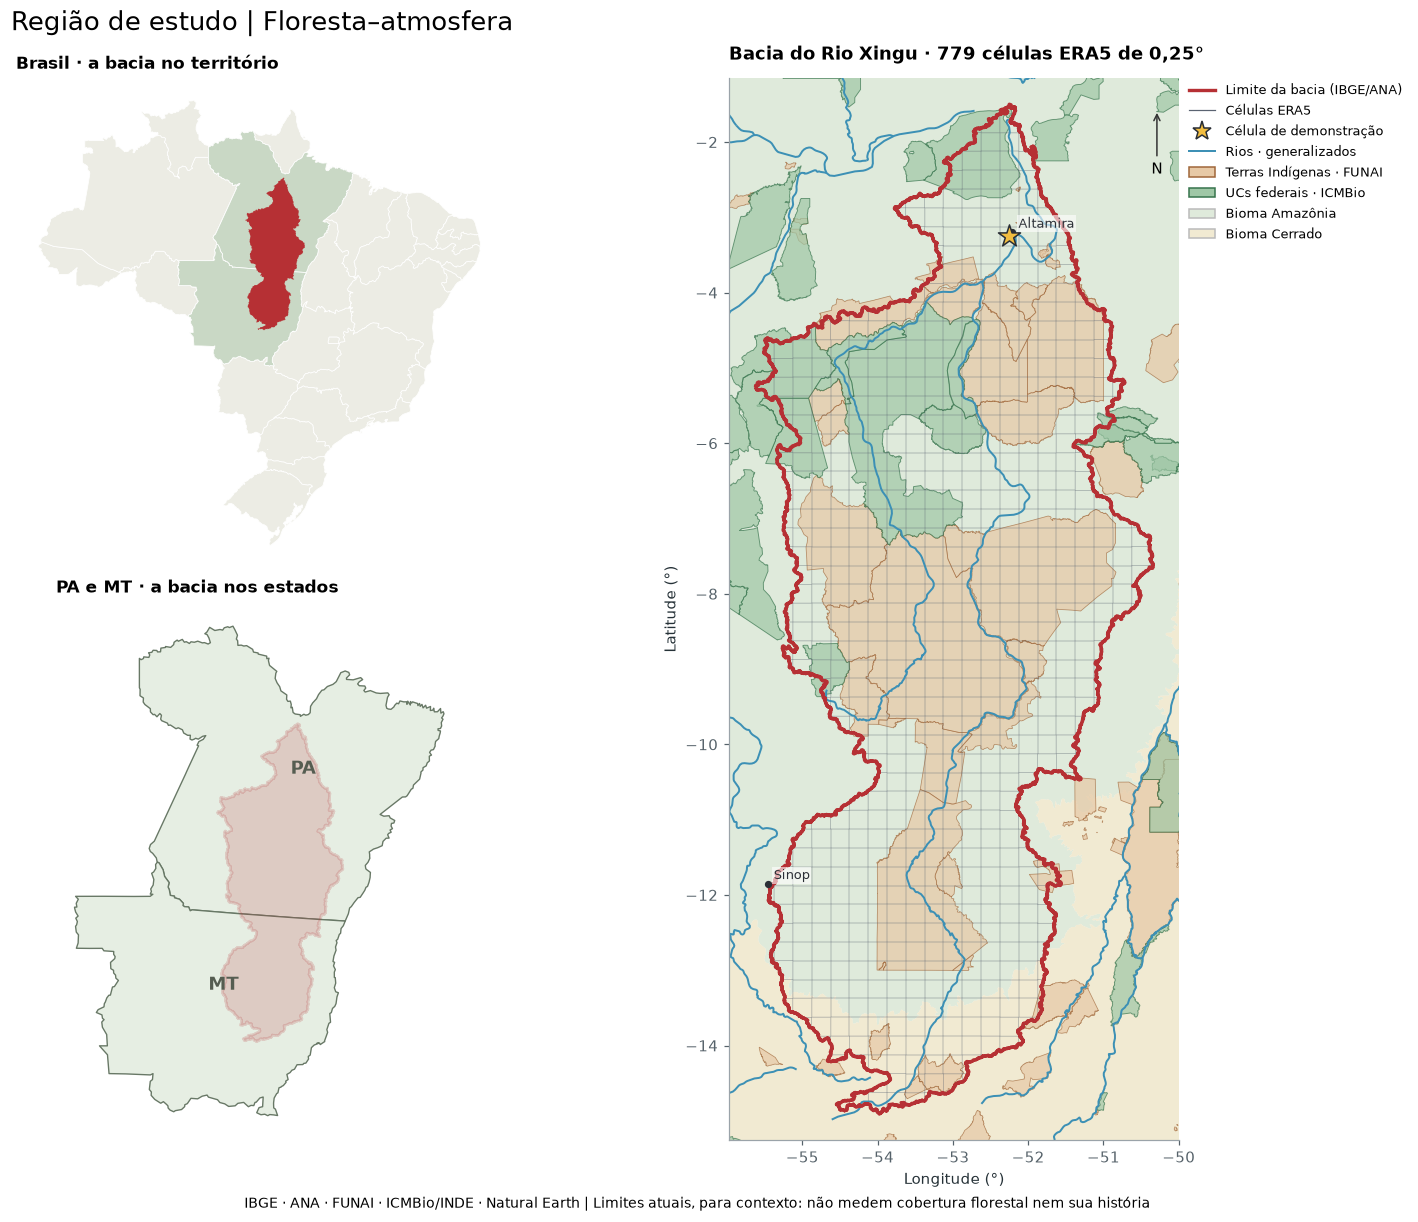

In [2]:
from amazon_chaos.atlas import biome_shares, load_basin_context, plot_basin_region

BASIN = gpd.read_file(CFG['spatial']['basin_source'])
CONTEXT = load_basin_context('data/external/xingu/contexto')
fig = plot_basin_region(CFG, BASIN, CELLS, CONTEXT, 'Bacia do Rio Xingu')
save(fig, FIGURES, '01_onde_estamos')
plt.show()

In [3]:
equal_area = BASIN.to_crs('EPSG:6933')
basin_km2 = float(equal_area.area.sum() / 1e6)
shares = biome_shares(BASIN, CONTEXT)
protected = {}
for layer, name_col in [('tis', 'terrai_nome'), ('ucs', 'nomeuc')]:
    if layer in CONTEXT:
        inside = gpd.overlay(CONTEXT[layer].to_crs('EPSG:6933'), equal_area[['geometry']],
                             how='intersection', keep_geom_type=True)
        inside['km2'] = inside.area / 1e6
        protected[layer] = inside
union = gpd.GeoSeries(pd.concat([p.geometry for p in protected.values()]), crs='EPSG:6933')
protected_km2 = float(union.union_all().area / 1e6)
lines = [f'- **Área da bacia:** {basin_km2:,.0f} km² (um pouco maior que a Espanha).']
lines += [f'- **{b}:** {km2:,.0f} km² ({100 * km2 / basin_km2:.0f}% da bacia)'
          for b, km2 in shares.items()]
if 'tis' in protected:
    lines.append(f"- **Terras Indígenas:** {protected['tis'].terrai_nome.nunique()} com "
                 f"área na bacia, somando {protected['tis'].km2.sum():,.0f} km².")
lines.append(f'- **TIs + UCs federais (sem dupla contagem):** {protected_km2:,.0f} km² '
             f'({100 * protected_km2 / basin_km2:.0f}% da bacia).')
show_md(('\n'.join(lines)))
if 'tis' in protected:
    top = (protected['tis'].groupby('terrai_nome').km2.sum().sort_values(ascending=False)
           .head(8).round(0).rename('km² dentro da bacia').to_frame())
    display(top)

- **Área da bacia:** 508.627 km² (um pouco maior que a Espanha).
- **Amazônia:** 474.166 km² (93% da bacia)
- **Cerrado:** 34.464 km² (7% da bacia)
- **Terras Indígenas:** 33 com área na bacia, somando 202.160 km².
- **TIs + UCs federais (sem dupla contagem):** 271.955 km² (53% da bacia).

,km² dentro da bacia
terrai_nome,
Menkragnoti,49289.0
Kayapó,32812.0
Parque do Xingu,26400.0
Trincheira Bacaja,16254.0
Baú,15385.0
Araweté Igarapé Ipixuna,9402.0
Apyterewa,7737.0
Capoto/Jarina,6341.0


> 💡 **Por que a bacia inteira?** A bacia é uma unidade física (a água, a umidade e parte
> da circulação local se organizam por ela) e contém, num mesmo recorte, o gradiente
> floresta úmida → transição com o Cerrado, e áreas protegidas ao lado de fronteiras agrícolas. O preço é a
> heterogeneidade: a **média da bacia mistura climas diferentes**, e por isso quase toda
> análise abaixo aparece também como mapa ou perfil norte–sul.

## 🛰️ 2. De onde vêm estes números?

Usamos a **reanálise ERA5** do ECMWF/Copernicus: um modelo de previsão do tempo que, hora a
hora desde 1940, é corrigido por milhões de observações (satélites, estações, radiossondas).
O resultado é um "mapa do tempo" completo, sem buracos, numa grade de 0,25° (~28 km).
**Não é uma medição de termômetro em cada célula**: é a melhor estimativa física consistente
com as observações disponíveis.

Baixamos seis variáveis horárias: temperatura e ponto de orvalho a 2 m, pressão à superfície,
vento a 10 m (duas componentes) e precipitação. Delas derivamos umidade relativa, umidade
específica, déficit de pressão de vapor (VPD) e velocidade do vento; depois, estatísticas
diárias no **horário local (UTC−3)**, só quando o dia tem as 24 horas completas.

In [4]:
jobs = plan_edh_requests(CFG, '1990-01-01', '2024-12-31')
rows = []
for job in jobs:
    manifest = job_directory(CFG, job) / 'manifest.json'
    if manifest.exists():
        m = json.loads(manifest.read_text())
        rows.append({'mês UTC': job['month'], 'MiB': m['files'][0]['size_bytes'] / 2**20,
                     'horas': m['quality']['n_hours'], 'baixado em': m['retrieved_utc'][:10]})
inventory = pd.DataFrame(rows)
n_cells = int(INSIDE.sum())
values = int(inventory.horas.sum()) * SUMMARY.sizes['latitude'] * SUMMARY.sizes['longitude'] * 6
show_md((
    f'**{len(inventory)} de {len(jobs)} meses** baixados e validados (SHA-256, horas, grade, '
    f'unidades, zero valores ausentes) · **{inventory.MiB.sum() / 1024:.2f} GiB** · '
    f'**{values / 1e9:.2f} bilhões** de valores horários.'
))
possible = int(SUMMARY.days_in_year.sum()) * n_cells
quality = pd.DataFrame([
    {'variável': LABELS[v], 'célula-dias completos': int(SUMMARY[f'complete_days_{v}'].sum()),
     'possíveis': possible}
    for v in ['t2m', 'tmax', 'rh', 'vpd', 'wind', 'precip']
])
quality['completude (%)'] = (100 * quality['célula-dias completos'] / quality.possíveis).round(4)
display(quality)

**421 de 421 meses** baixados e validados (SHA-256, horas, grade, unidades, zero valores ausentes) · **2,22 GiB** · **2,37 bilhões** de valores horários.

,variável,célula-dias completos,possíveis,completude (%)
0,Temperatura média (°C),9958736,9958736,100.0
1,Temperatura máxima (°C),9958736,9958736,100.0
2,Umidade relativa (%),9958736,9958736,100.0
3,Déficit de pressão de vapor (kPa),9958736,9958736,100.0
4,Vento a 10 m (m/s),9958736,9958736,100.0
5,Chuva (mm),9958736,9958736,100.0


> ⚠️ **Precisão do espelho Earth Data Hub.** Os dados vieram do espelho Zarr do ERA5 no
> Earth Data Hub (DestinE), muito mais rápido que a fila do CDS. Ele guarda cada número com
> ~10 bits de mantissa: erro relativo de até 0,05%, **sem viés** (até 0,125 °C numa hora; na
> média diária de uma célula, ~0,015 °C típico). Na média da região, esse ruído praticamente
> desaparece. Para métodos sensíveis a ruído (Lyapunov, recorrência) em **células
> individuais**, a sensibilidade será testada contra o CDS. Detalhes: `docs/DECISIONS.md`, D-007.

## 📈 3. Do cubo de dados à série da região

Cada variável diária é um **cubo**: `valor[dia, latitude, longitude]`. Para contar a história
da região como um todo, resumimos cada dia numa **média ponderada pela área** que cada
célula ocupa dentro da região. É isso que chamamos de série regional. Abaixo, os 12.784 dias
de temperatura e de chuva.

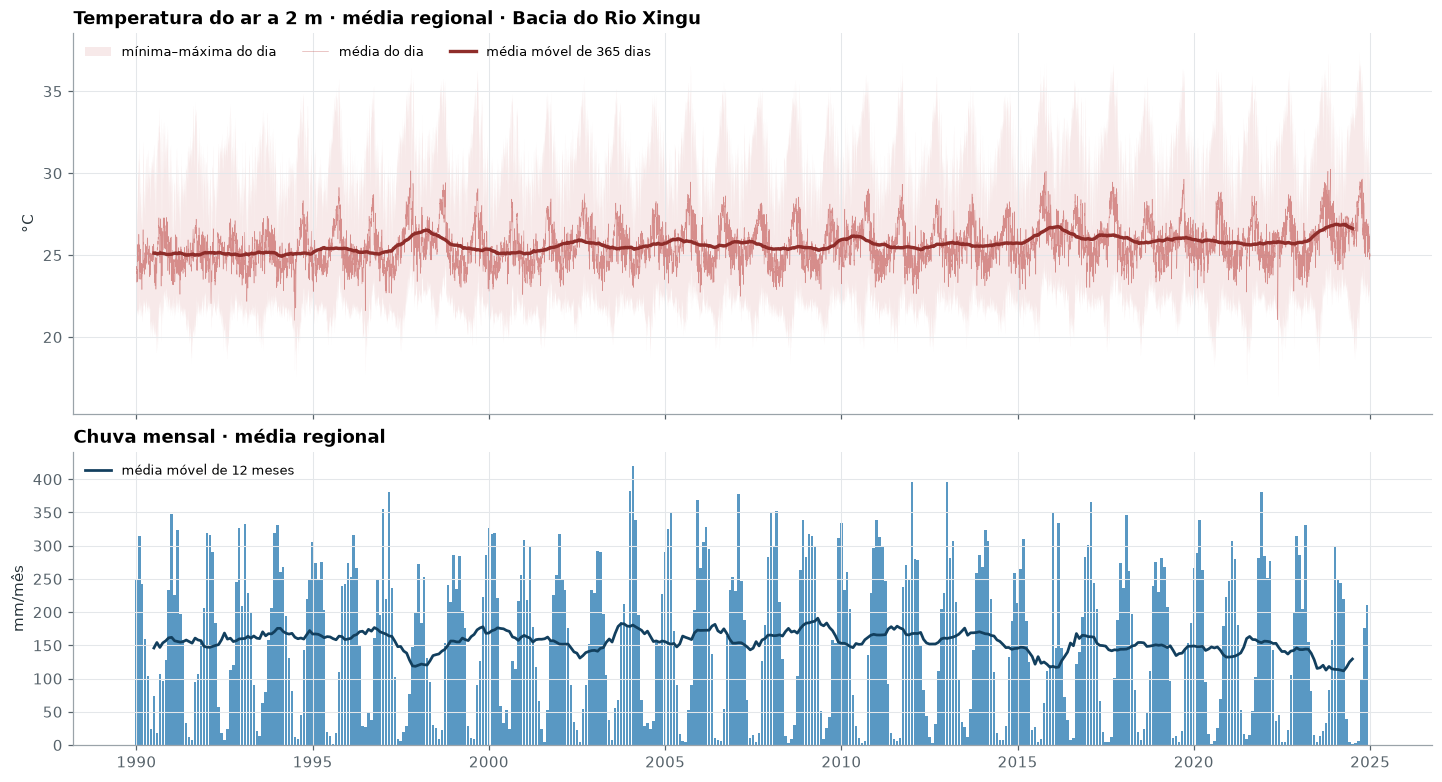

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, layout='constrained',
                               height_ratios=[1.3, 1])
ax1.fill_between(DAILY.index, DAILY.tmin, DAILY.tmax, color=COLORS['t2m'], alpha=.12,
                 lw=0, label='mínima–máxima do dia')
ax1.plot(DAILY.index, DAILY.t2m, color=COLORS['t2m'], lw=.35, alpha=.6, label='média do dia')
ax1.plot(DAILY.t2m.rolling(365, center=True).mean(), color=COLORS['tmax'], lw=2.2,
         label='média móvel de 365 dias')
ax1.set(ylabel='°C', title=f'Temperatura do ar a 2 m · média regional · {REGION}')
ax1.legend(ncol=3, loc='upper left', fontsize=8.5)
monthly_rain = DAILY.precip.resample('MS').sum()
ax2.bar(monthly_rain.index, monthly_rain, width=25, color=COLORS['precip'], alpha=.8)
ax2.plot(monthly_rain.rolling(12, center=True).mean(), color='#123f5e', lw=1.8,
         label='média móvel de 12 meses')
ax2.set(ylabel='mm/mês', title='Chuva mensal · média regional')
ax2.legend(loc='upper left', fontsize=8.5)
ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
save(fig, FIGURES, '02_serie_35_anos')
plt.show()

### Um ano de perto: 2024 contra o "ano normal"

A linha tracejada é o **ciclo anual médio de 1991–2020** para cada dia do calendário
(suavizado em 31 dias). Assim dá para ver quando 2024, um ano de seca histórica na
Amazônia, esteve acima ou abaixo do esperado para aquela época do ano.

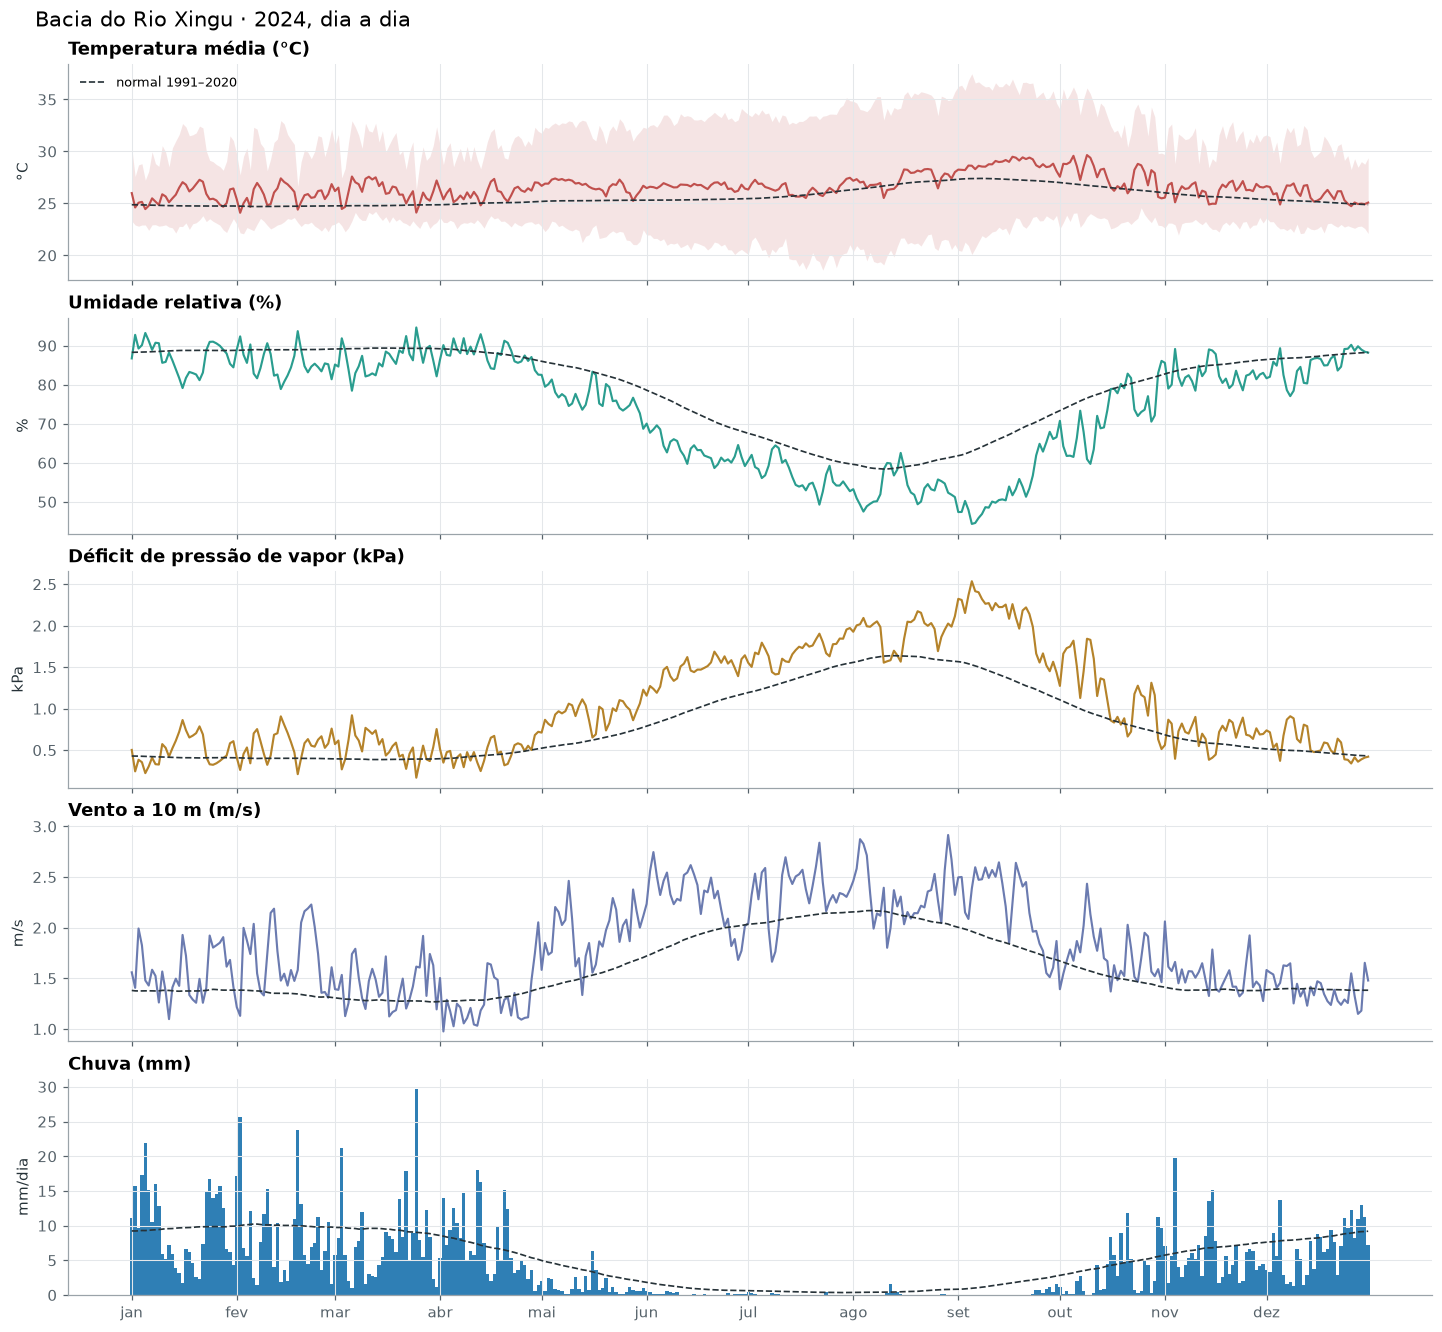

Em 2024, **326 de 366 dias** ficaram acima da normal de temperatura; anomalia média de **+1,01 °C**.

In [6]:
year = DAILY.loc['2024']
panels = [('t2m', '°C'), ('rh', '%'), ('vpd', 'kPa'), ('wind', 'm/s'), ('precip', 'mm/dia')]
fig, axes = plt.subplots(len(panels), 1, figsize=(13, 12), sharex=True, layout='constrained')
for ax, (var, unit) in zip(axes, panels):
    if var == 'precip':
        ax.bar(year.index, year.precip, color=COLORS['precip'], width=1)
        normal = anomalies(DAILY.precip, BASE)[1]
    else:
        ax.plot(year.index, year[var], color=COLORS[var], lw=1.4)
        normal = anomalies(DAILY[var], BASE)[1]
    ax.plot(year.index, normal.reindex(year.index.dayofyear).to_numpy(), color=COLORS['ink'],
            ls='--', lw=1.1, label='normal 1991–2020')
    ax.set(ylabel=unit, title=LABELS[var])
axes[0].fill_between(year.index, year.tmin, year.tmax, color=COLORS['t2m'], alpha=.15, lw=0)
axes[0].legend(loc='upper left', fontsize=8.5)
axes[-1].set_xticks(pd.date_range('2024-01-01', periods=12, freq='MS'), MONTHS)
fig.suptitle(f'{REGION} · 2024, dia a dia', fontsize=14, x=.02, ha='left')
save(fig, FIGURES, '03_ano_2024')
plt.show()
hot = anomalies(DAILY.t2m, BASE)[0].loc['2024']
show_md((f'Em 2024, **{int((hot > 0).sum())} de {len(hot)} dias** ficaram acima da '
                 f'normal de temperatura; anomalia média de **{hot.mean():+.2f} °C**.'))

## 🗓️ 4. O ritmo do ano

O **climograma** resume o ano típico da normal 1991–2020: barras de chuva mensal e a
temperatura média, com a faixa entre as médias das mínimas e das máximas. Adotamos o limiar
operacional de **100 mm/mês** para "mês seco", comum em estudos amazônicos (abaixo disso, a
floresta tende a consumir mais água do que recebe).

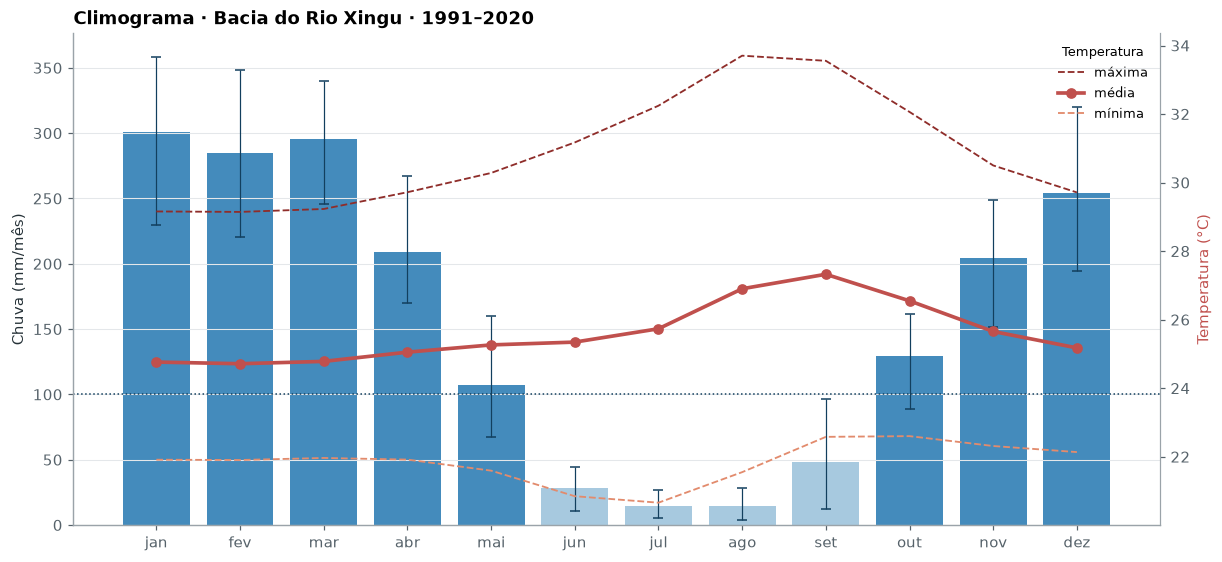

Chuva anual normal: **1.891 mm** (entre 1.459 e 2.153 mm nos anos da normal). Meses secos (< 100 mm): **jun, jul, ago, set**. As barras de erro vão do 10º ao 90º percentil entre os anos: a variação de um ano para outro.

In [7]:
base_daily = DAILY.loc[BASE[0]:BASE[1]]
agg = {c: 'mean' for c in DAILY.columns} | {'precip': 'sum'}
monthly = base_daily.resample('MS').agg(agg)
normals = monthly.groupby(monthly.index.month).mean()
p10 = monthly.groupby(monthly.index.month).quantile(.1)
p90 = monthly.groupby(monthly.index.month).quantile(.9)
dry = [MONTHS[m - 1] for m in normals.index[normals.precip < 100]]

fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
bars = ax.bar(MONTHS, normals.precip, color=[COLORS['precip'] if v >= 100 else '#9ec3dc'
                                             for v in normals.precip], alpha=.9)
ax.errorbar(MONTHS, normals.precip, yerr=[normals.precip - p10.precip, p90.precip - normals.precip],
            fmt='none', ecolor='#123f5e', elinewidth=.8, capsize=3)
ax.axhline(100, color='#123f5e', ls=':', lw=1)
ax.set(ylabel='Chuva (mm/mês)', title=f'Climograma · {REGION} · 1991–2020')
ax.grid(axis='x', visible=False)
twin = ax.twinx()
twin.plot(MONTHS, normals.tmax, color=COLORS['tmax'], ls='--', lw=1.2, label='máxima')
twin.plot(MONTHS, normals.t2m, color=COLORS['t2m'], marker='o', lw=2.4, label='média')
twin.plot(MONTHS, normals.tmin, color=COLORS['tmin'], ls='--', lw=1.2, label='mínima')
twin.legend(loc='upper right', fontsize=8.5, title='Temperatura', title_fontsize=8.5)
twin.set_ylabel('Temperatura (°C)', color=COLORS['t2m'])
twin.grid(False)
twin.spines['right'].set_visible(True)
save(fig, FIGURES, '04_climograma')
plt.show()
annual_rain = monthly.precip.groupby(monthly.index.year).sum()
show_md((
    f'Chuva anual normal: **{annual_rain.mean():,.0f} mm** (entre {annual_rain.min():,.0f} e '
    f'{annual_rain.max():,.0f} mm nos anos da normal). Meses secos (< 100 mm): '
    f'**{", ".join(dry) if dry else "nenhum"}**. As barras de erro vão do 10º ao 90º '
    'percentil entre os anos: a variação de um ano para outro.'
))

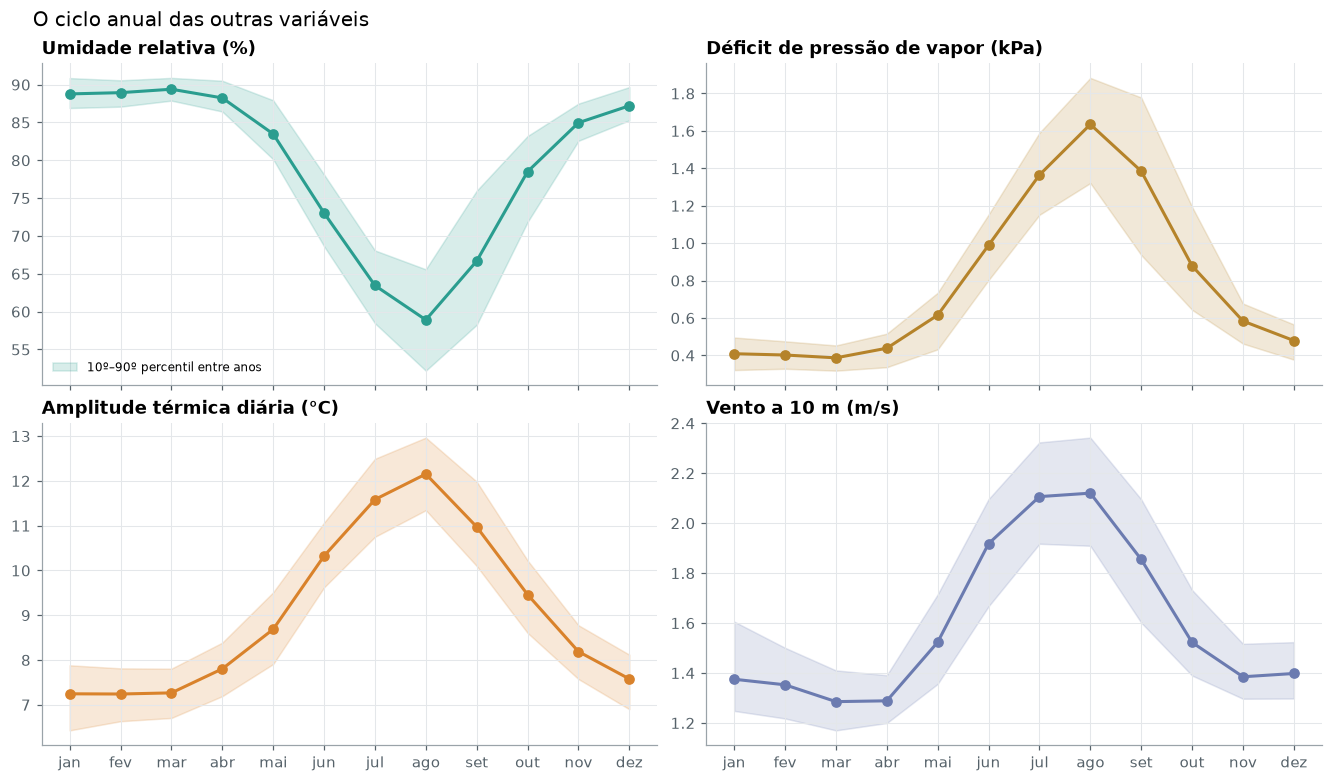

,jan,fev,mar,abr,mai,jun,jul,ago,set,out,nov,dez
Temperatura média (°C),24.76,24.71,24.78,25.05,25.26,25.34,25.73,26.90,27.32,26.55,25.65,25.18
Temperatura mínima (°C),21.91,21.90,21.96,21.92,21.59,20.85,20.66,21.55,22.58,22.60,22.31,22.13
Temperatura máxima (°C),29.16,29.14,29.23,29.72,30.28,31.17,32.24,33.70,33.55,32.06,30.50,29.71
Chuva (mm),300.58,284.99,295.85,208.86,106.97,28.05,14.55,14.81,47.89,129.66,204.27,254.18
Umidade relativa (%),88.77,88.94,89.39,88.24,83.48,73.04,63.46,58.91,66.69,78.50,84.97,87.21
Déficit de pressão de vapor (kPa),0.41,0.40,0.39,0.44,0.62,0.99,1.36,1.63,1.38,0.88,0.58,0.48
Vento a 10 m (m/s),1.38,1.35,1.29,1.29,1.52,1.92,2.11,2.12,1.85,1.52,1.39,1.40


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained', sharex=True)
for ax, var in zip(axes.flat, ['rh', 'vpd', 'dtr', 'wind']):
    ax.fill_between(MONTHS, p10[var], p90[var], color=COLORS[var], alpha=.18,
                    label='10º–90º percentil entre anos')
    ax.plot(MONTHS, normals[var], color=COLORS[var], marker='o', lw=2)
    ax.set(title=LABELS[var])
axes[0, 0].legend(fontsize=8)
fig.suptitle('O ciclo anual das outras variáveis', fontsize=13, x=.02, ha='left')
save(fig, FIGURES, '05_ciclo_anual')
plt.show()
table = normals[['t2m', 'tmin', 'tmax', 'precip', 'rh', 'vpd', 'wind']].copy()
table.index = MONTHS
display(table.round(2).rename(columns={k: LABELS[k] for k in table.columns}).T)

> 💡 **Leitura:** na estação seca, a chuva despenca, a umidade relativa cai, o **VPD** (a
> "sede" do ar, quanto vapor ainda caberia nele) e a amplitude térmica sobem. O VPD é uma das
> variáveis mais ligadas ao estresse da floresta e ao risco de fogo; por isso ele aparece
> tanto neste caderno.

## 🧭 5. A geografia do clima

Agora o mesmo resumo da normal 1991–2020, **célula por célula**. Cada cor é um polígono ERA5
(recortado no limite da região). As escalas são próprias de cada painel.

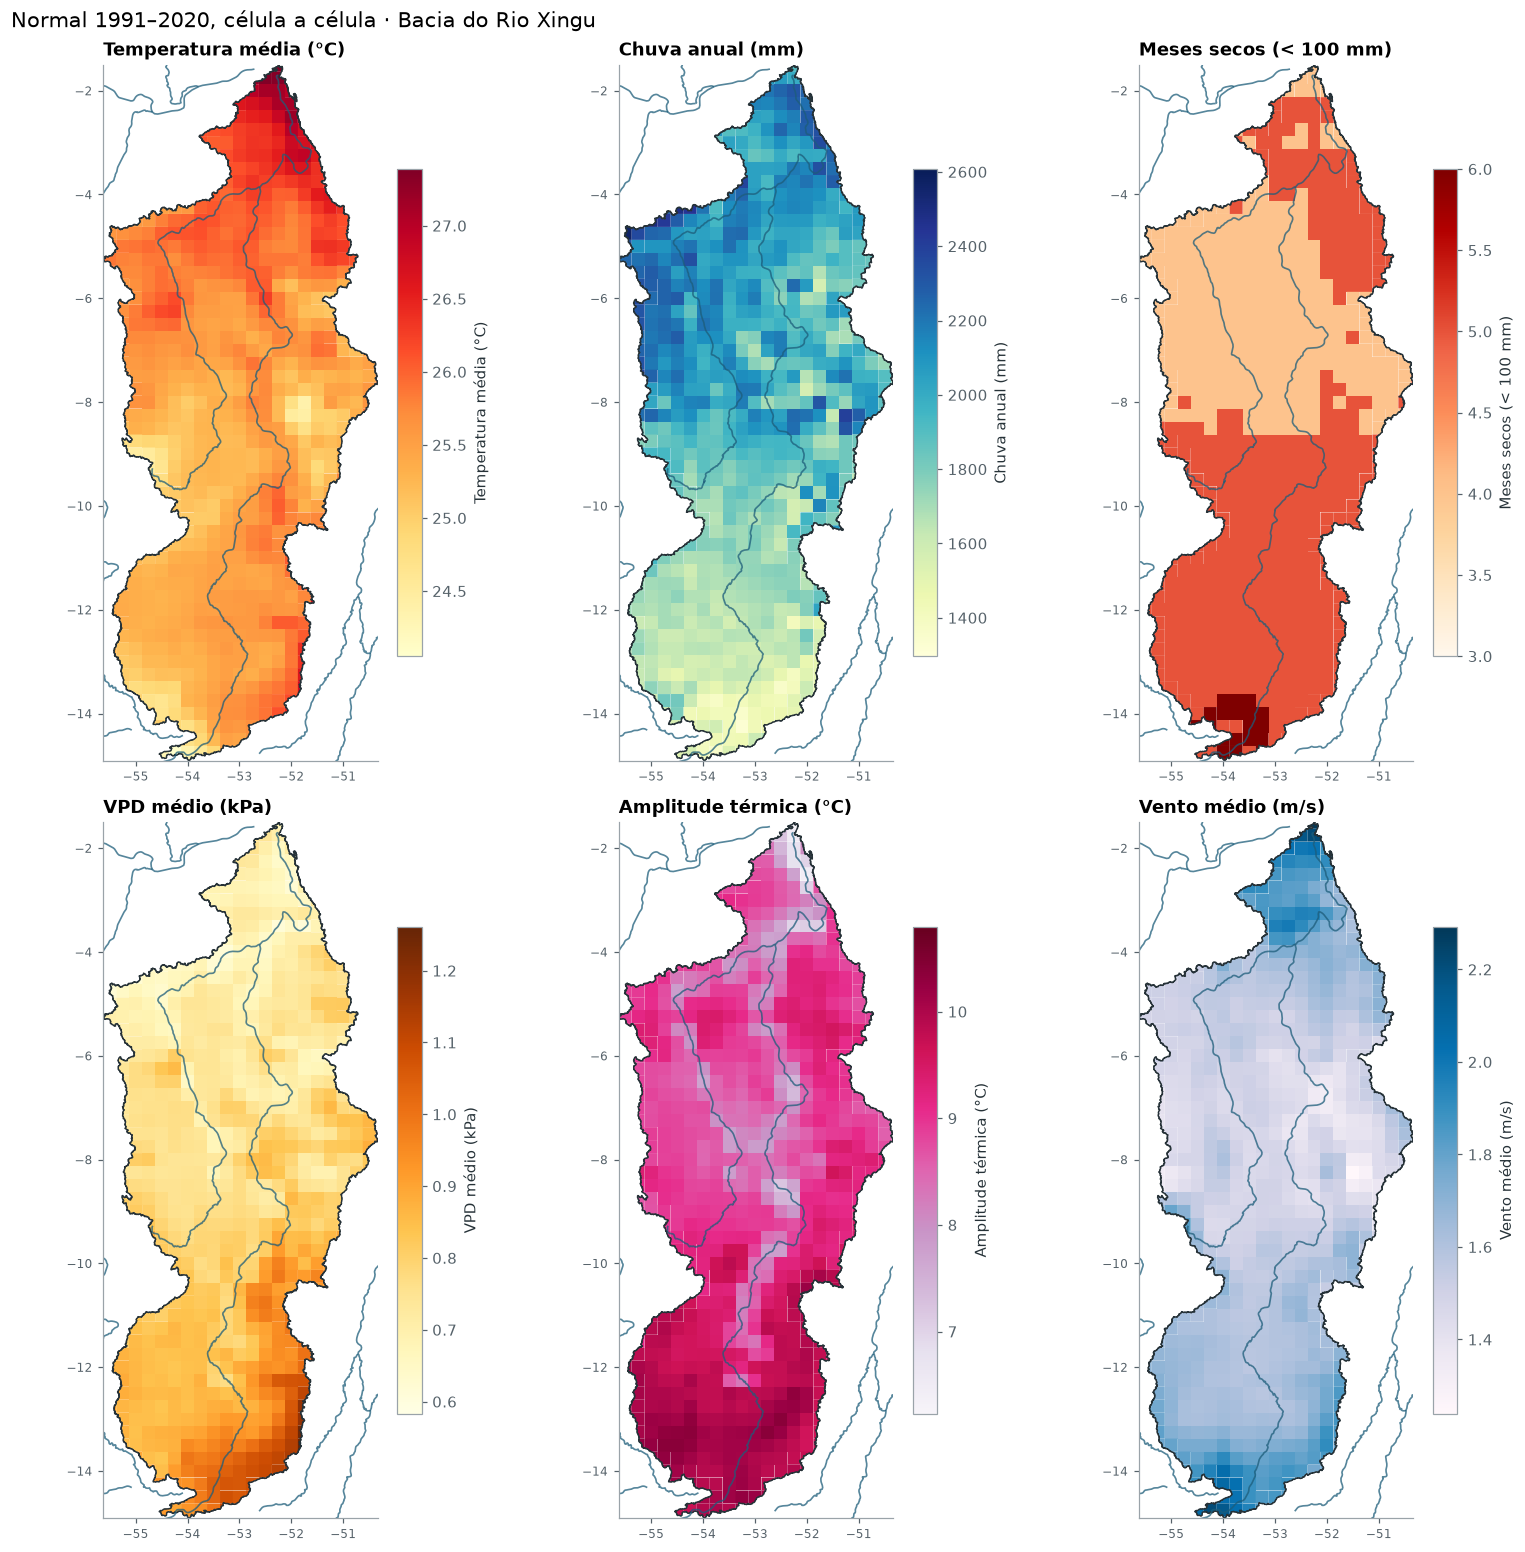

In [9]:
in_base = SUMMARY.sel(month=slice(BASE[0], BASE[1]))
by_month = in_base[[f'cell_{v}' for v in ['t2m', 'precip', 'vpd', 'dtr', 'wind', 'rh']]] \
    .groupby('month.month').mean()
fields = {
    't2m': (by_month.cell_t2m.mean('month'), 'YlOrRd', 'Temperatura média (°C)'),
    'precip': (by_month.cell_precip.sum('month', min_count=12), 'YlGnBu', 'Chuva anual (mm)'),
    'dry': ((by_month.cell_precip < 100).sum('month').where(INSIDE), 'OrRd',
            'Meses secos (< 100 mm)'),
    'vpd': (by_month.cell_vpd.mean('month'), 'YlOrBr', 'VPD médio (kPa)'),
    'dtr': (by_month.cell_dtr.mean('month'), 'PuRd', 'Amplitude térmica (°C)'),
    'wind': (by_month.cell_wind.mean('month'), 'PuBu', 'Vento médio (m/s)'),
}
outline = BASIN if 'BASIN' in globals() else None
rivers = CONTEXT.get('rios')
tall = SUMMARY.sizes['latitude'] > 2 * SUMMARY.sizes['longitude']
fig, axes = plt.subplots(2 if tall else 3, 3 if tall else 2,
                         figsize=(14, 14) if tall else (12, 13), layout='constrained')
for ax, (key, (field, cmap, label)) in zip(axes.flat, fields.items()):
    map_cells(ax, CELLS, field, cmap, label, outline=outline, lines=rivers)
    ax.set_title(label)
fig.suptitle(f'Normal 1991–2020, célula a célula · {REGION}', fontsize=14, x=.02, ha='left')
save(fig, FIGURES, '06_mapas_normal')
plt.show()

### O gradiente norte–sul

Como a bacia é comprida, uma forma compacta de ver a geografia é tirar a média de cada
"fatia" de latitude (ponderada pela área dentro da bacia). Ao sul, nas cabeceiras, perto
da transição com o Cerrado, a estação seca é mais longa e o ar mais seco; ao norte, a
floresta úmida.

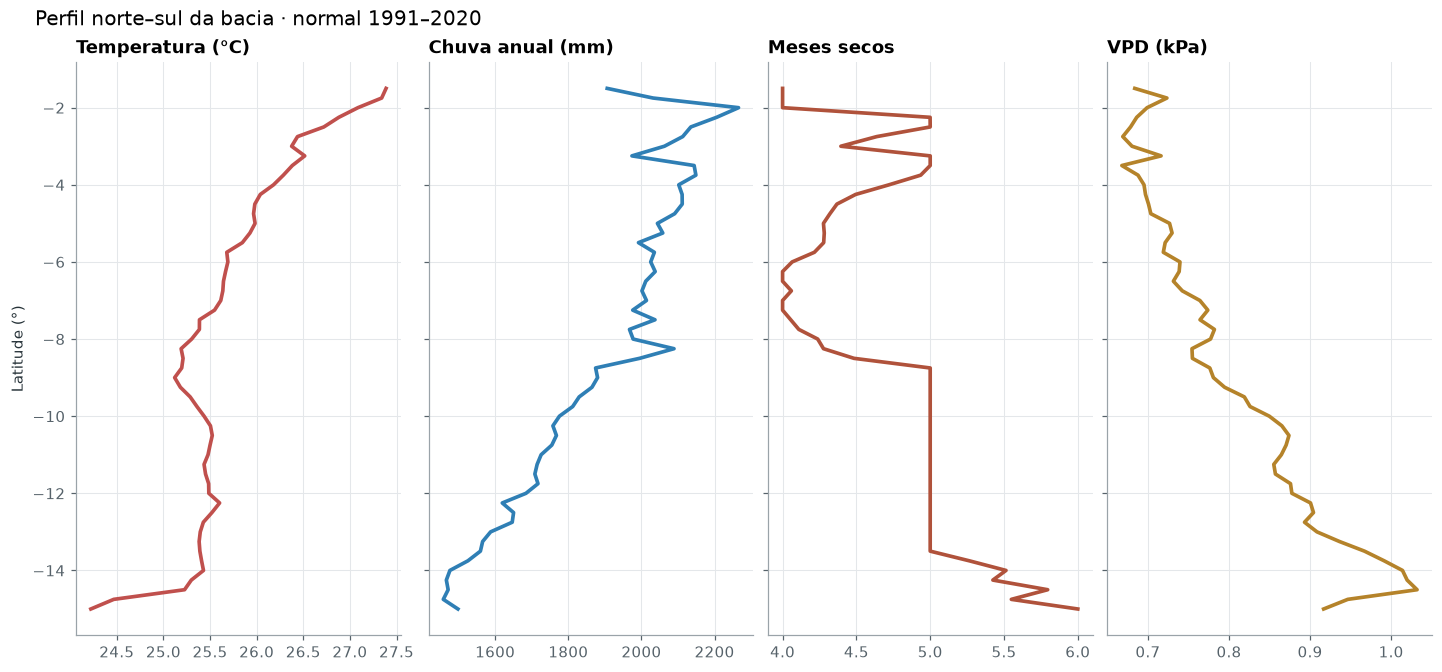

Dois graus mais ao norte (-1,5° a -3,2°) × dois graus mais ao sul (-13,2° a -15,0°): chuva **2.087 × 1.503 mm/ano**, meses secos **4,5 × 5,4**, VPD **0,69 × 0,98 kPa**.

In [10]:
w = SUMMARY.weight_km2
profile = pd.DataFrame({
    key: (field.fillna(0) * w).sum('longitude') / w.sum('longitude')
    for key, (field, _, _) in fields.items()
}, index=SUMMARY.latitude.values)[w.sum('longitude').values > 0]
fig, axes = plt.subplots(1, 4, figsize=(13, 6), sharey=True, layout='constrained')
for ax, (key, color, label) in zip(axes, [
    ('t2m', COLORS['t2m'], 'Temperatura (°C)'), ('precip', COLORS['precip'], 'Chuva anual (mm)'),
    ('dry', '#b0523b', 'Meses secos'), ('vpd', COLORS['vpd'], 'VPD (kPa)')]):
    ax.plot(profile[key], profile.index, color=color, lw=2.4)
    ax.set(title=label)
axes[0].set_ylabel('Latitude (°)')
fig.suptitle('Perfil norte–sul da bacia · normal 1991–2020', fontsize=13, x=.02, ha='left')
save(fig, FIGURES, '07_perfil_norte_sul')
plt.show()
north, south = profile.iloc[:8].mean(), profile.iloc[-8:].mean()
show_md((
    f'Dois graus mais ao norte ({profile.index[0]:.1f}° a {profile.index[7]:.1f}°) × dois graus '
    f'mais ao sul ({profile.index[-8]:.1f}° a {profile.index[-1]:.1f}°): chuva '
    f'**{north.precip:,.0f} × {south.precip:,.0f} mm/ano**, meses secos '
    f'**{north.dry:.1f} × {south.dry:.1f}**, VPD **{north.vpd:.2f} × {south.vpd:.2f} kPa**.'
))

## ☔ 6. Duas estações, dois mapas

Comparamos o trimestre mais chuvoso e o mais seco da normal (escolhidos pela chuva média da
região). Chuva e VPD se opõem: onde e quando falta água, o ar "puxa" mais vapor da vegetação.

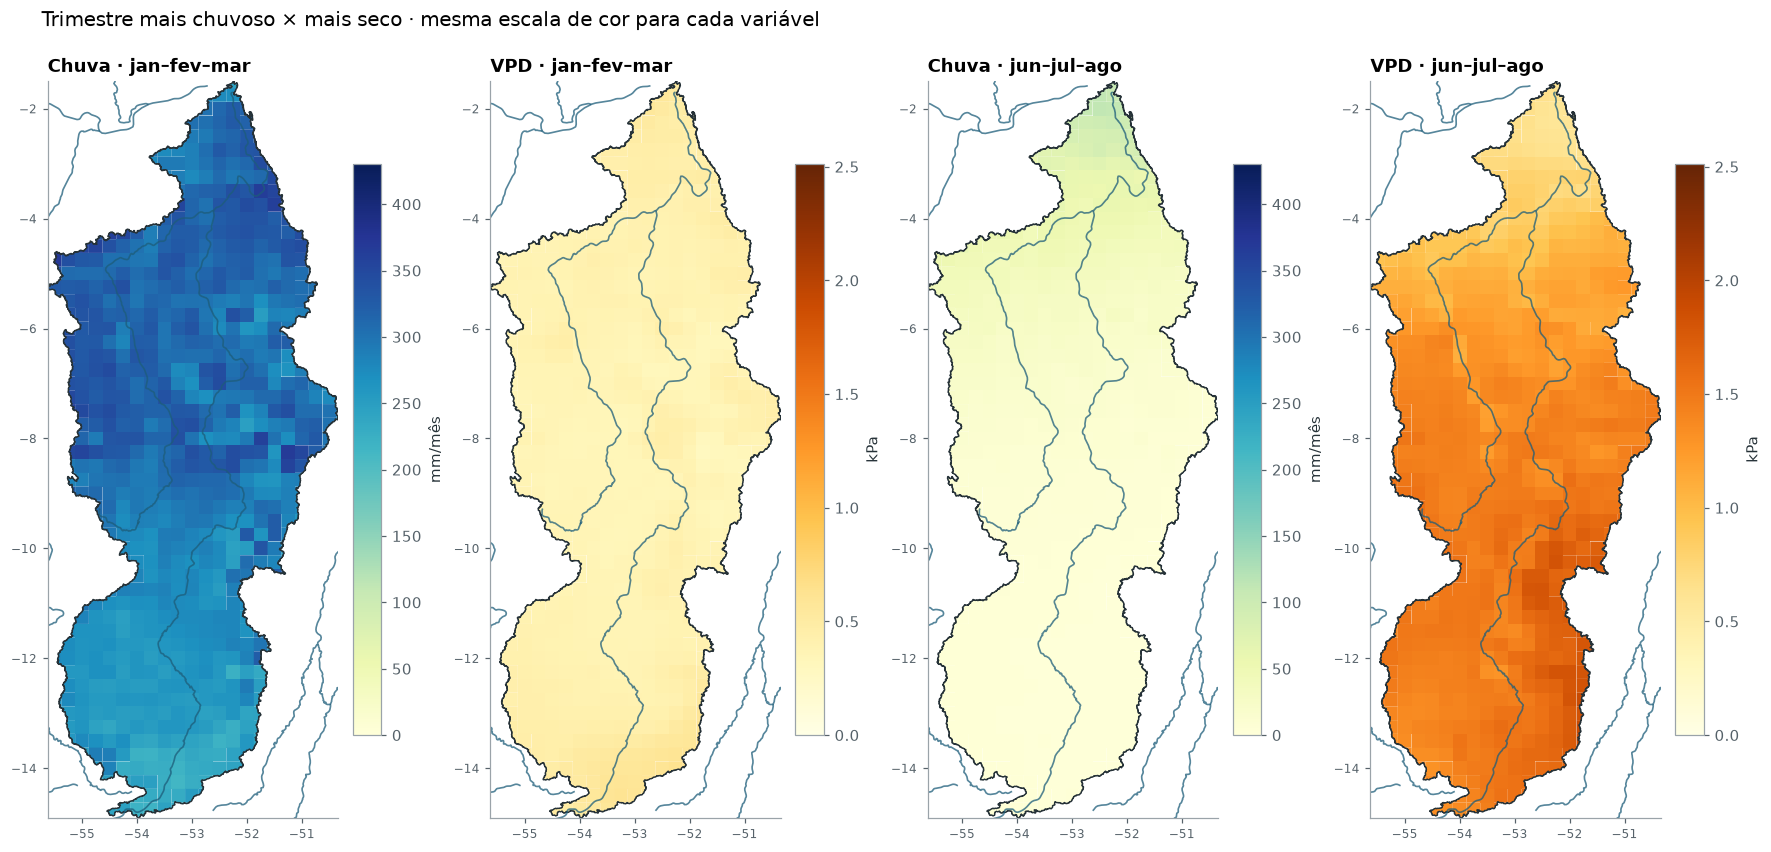

In [11]:
rolling = pd.concat([normals.precip, normals.precip.iloc[:2]]).rolling(3).sum().iloc[2:]
rolling.index = [(m - 3) % 12 + 1 for m in range(3, 15)]  # mês inicial de cada trimestre
wet_start, dry_start = int(rolling.idxmax()), int(rolling.idxmin())
quarter = lambda start: [(start + k - 1) % 12 + 1 for k in range(3)]
names = {s: '–'.join(MONTHS[m - 1] for m in quarter(s)) for s in [wet_start, dry_start]}
fig, axes = plt.subplots(1 if tall else 2, 4 if tall else 2, figsize=(16, 7.8) if tall else (12, 10),
                         layout='constrained')
axes = np.reshape(axes, (2, 2))  # linha 0: trimestre chuvoso; linha 1: seco
for row, start in enumerate([wet_start, dry_start]):
    sel = by_month.sel(month=quarter(start))
    map_cells(axes[row, 0], CELLS, sel.cell_precip.sum('month') / 3, 'YlGnBu', 'mm/mês',
              outline=outline, lines=rivers, vmin=0, vmax=float(by_month.cell_precip.max()))
    map_cells(axes[row, 1], CELLS, sel.cell_vpd.mean('month'), 'YlOrBr', 'kPa',
              outline=outline, lines=rivers, vmin=0, vmax=float(by_month.cell_vpd.max()))
    axes[row, 0].set_title(f'Chuva · {names[start]}')
    axes[row, 1].set_title(f'VPD · {names[start]}')
fig.suptitle('Trimestre mais chuvoso × mais seco · mesma escala de cor para cada variável',
             fontsize=13, x=.02, ha='left')
save(fig, FIGURES, '08_estacoes')
plt.show()

## ⏳ 7. 35 anos: o que mudou?

Para cada ano, calculamos a média (ou o total, para chuva) da região e a **anomalia** em
relação à normal 1991–2020. As "listras do aquecimento" (Ed Hawkins) mostram um ano por
faixa: azul, mais frio que a normal; vermelho, mais quente.

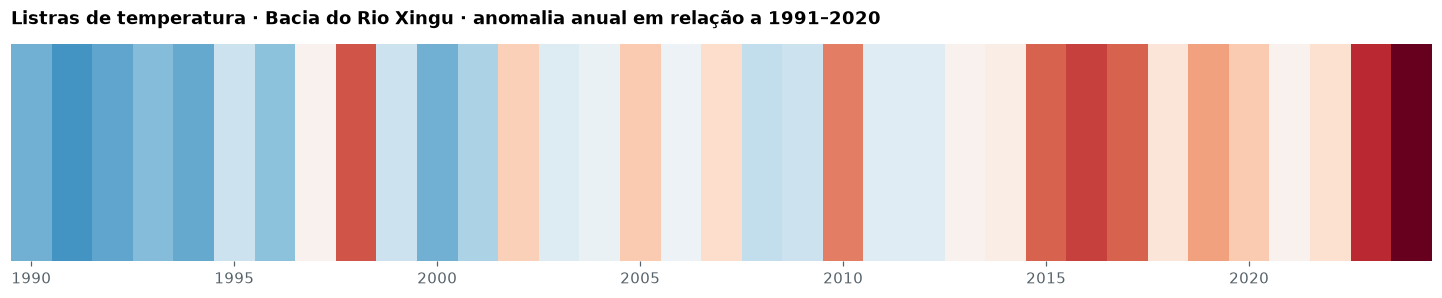

Ano mais quente: **2024** (+1,01 °C); mais frio: **1991** (-0,60 °C).

In [12]:
annual = DAILY.resample('YS').agg(agg)
annual.index = annual.index.year
annual['dry_spell'] = (SUMMARY.longest_dry_spell * SUMMARY.weight_km2).sum(('latitude', 'longitude')) \
    .values / float(SUMMARY.weight_km2.sum())
annual['hottest'] = DAILY.tmax.resample('YS').max().values
reference = annual.loc[1991:2020].mean()
anomaly = annual.t2m - reference.t2m
fig, ax = plt.subplots(figsize=(13, 2.6), layout='constrained')
limit = float(np.abs(anomaly).max())
ax.bar(anomaly.index, 1, width=1, color=plt.cm.RdBu_r((anomaly + limit) / (2 * limit)))
ax.set(xlim=(anomaly.index[0] - .5, anomaly.index[-1] + .5), yticks=[],
       title=f'Listras de temperatura · {REGION} · anomalia anual em relação a 1991–2020')
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
save(fig, FIGURES, '09_listras')
plt.show()
show_md((f'Ano mais quente: **{anomaly.idxmax()}** ({anomaly.max():+.2f} °C); '
                 f'mais frio: **{anomaly.idxmin()}** ({anomaly.min():+.2f} °C).'))

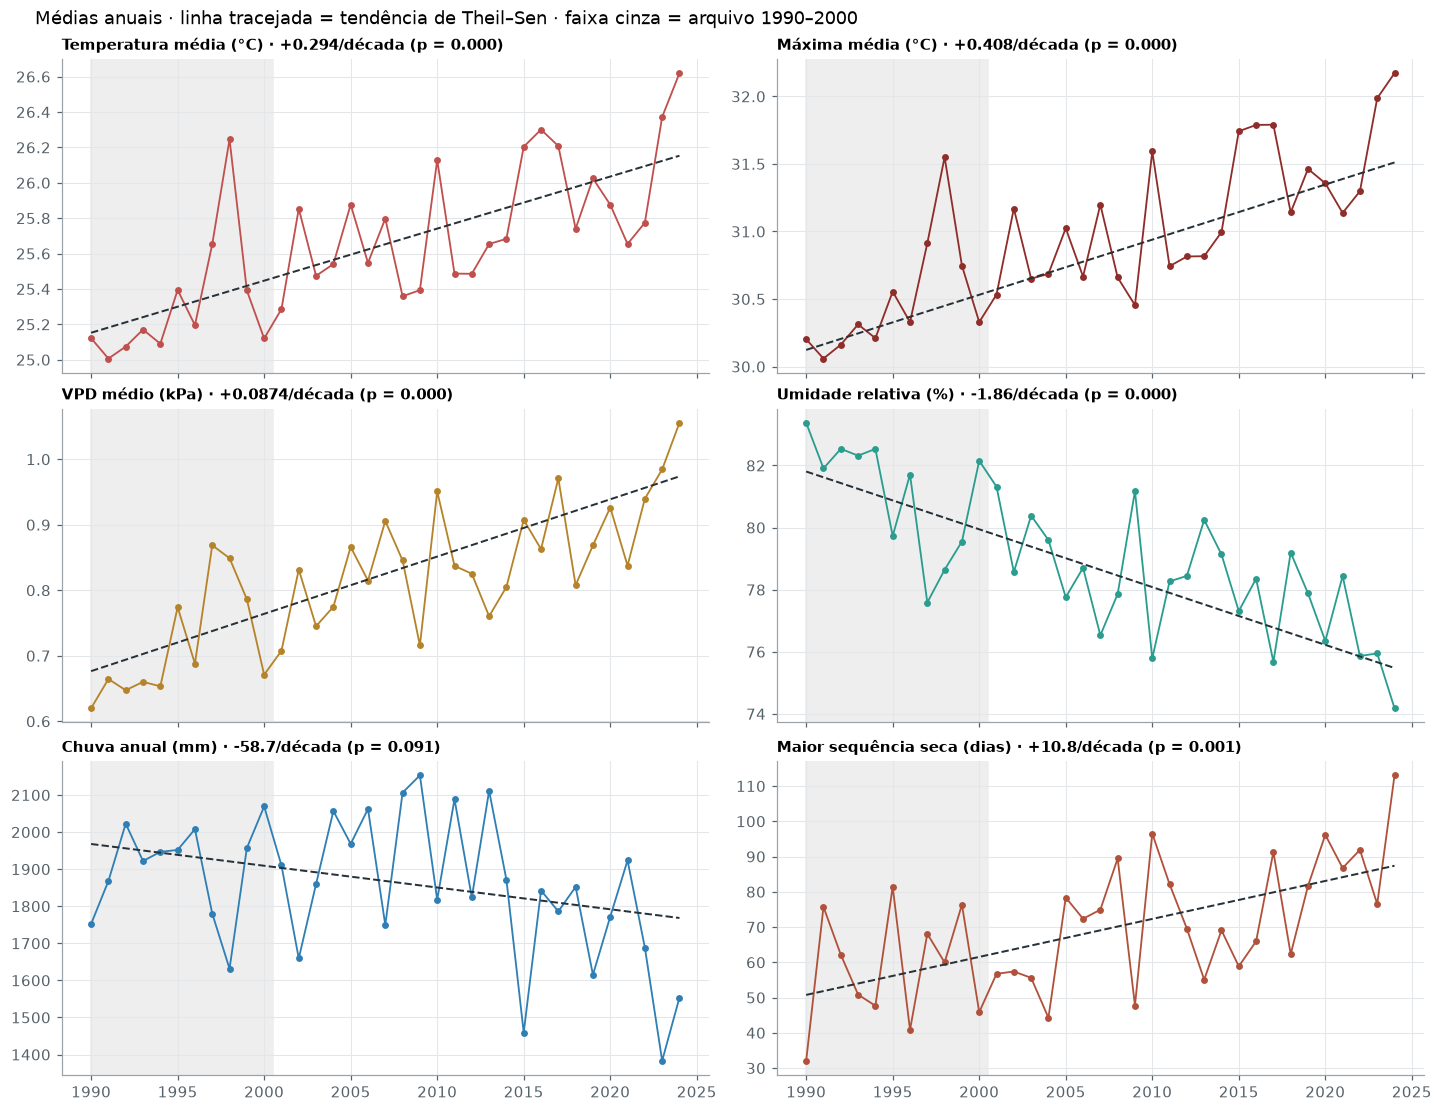

,tendência 1990–2024 (/década),p (1990–2024),tendência 2001–2024 (/década),p (2001–2024)
variável,,,,
Temperatura média (°C),+0.294,0.000,+0.293,0.002
Máxima média (°C),+0.408,0.000,+0.437,0.000
VPD médio (kPa),+0.087,0.000,+0.089,0.001
Umidade relativa (%),-1.861,0.000,-1.680,0.005
Chuva anual (mm),-58.691,0.091,-146.053,0.034
Maior sequência seca (dias),+10.774,0.001,+15.184,0.010


In [13]:
series = [('t2m', 'Temperatura média (°C)'), ('tmax', 'Máxima média (°C)'),
          ('vpd', 'VPD médio (kPa)'), ('rh', 'Umidade relativa (%)'),
          ('precip', 'Chuva anual (mm)'), ('dry_spell', 'Maior sequência seca (dias)')]
years = annual.index.values.astype(float)
rows = []
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True, layout='constrained')
for ax, (var, label) in zip(axes.flat, series):
    values = annual[var].values
    color = COLORS.get(var, '#b0523b')
    ax.plot(years, values, 'o-', color=color, ms=3.5, lw=1.2)
    slope, p = theil_sen(values, years)
    middle = np.nanmedian(values) - slope / 10 * np.nanmedian(years)
    ax.plot(years, middle + slope / 10 * years, color=COLORS['ink'], ls='--', lw=1.3)
    ax.axvspan(1990, 2000.5, color='#eeeeee', zorder=0)
    ax.set_title(f'{label} · {slope:+.3g}/década (p = {p:.3f})', fontsize=10)
    recent, recent_p = theil_sen(values[years >= 2001], years[years >= 2001])
    rows.append({'variável': label, 'tendência 1990–2024 (/década)': slope, 'p (1990–2024)': p,
                 'tendência 2001–2024 (/década)': recent, 'p (2001–2024)': recent_p})
fig.suptitle('Médias anuais · linha tracejada = tendência de Theil–Sen · faixa cinza = arquivo 1990–2000',
             fontsize=12, x=.02, ha='left')
save(fig, FIGURES, '10_series_anuais')
plt.show()
trends = pd.DataFrame(rows).set_index('variável')
display(trends.style.format('{:+.3f}', subset=[c for c in trends if 'tendência' in c])
        .format('{:.3f}', subset=[c for c in trends if c.startswith('p')])
        .background_gradient(cmap='Greens_r', subset=[c for c in trends if c.startswith('p')],
                             vmin=0, vmax=.2))

> 📏 **Sobre as tendências.** Theil–Sen é a mediana das inclinações entre todos os pares de
> anos: robusta a anos atípicos. O p-valor (Mann–Kendall) supõe anos independentes; com
> autocorrelação (El Niño, ciclos de vários anos) ele fica otimista. Leia os p-valores como
> indicação, não como prova, e lembre que 35 anos é pouco para separar tendência de
> variabilidade de décadas.

## 🧩 8. Onde mudou mais?

A mesma tendência de Theil–Sen, agora **célula por célula**. Pontinhos pretos marcam células
com p < 0,05 (com a ressalva de sempre: muitas células testadas ao mesmo tempo, e vizinhas
parecidas entre si, geram "significâncias" que não são independentes).

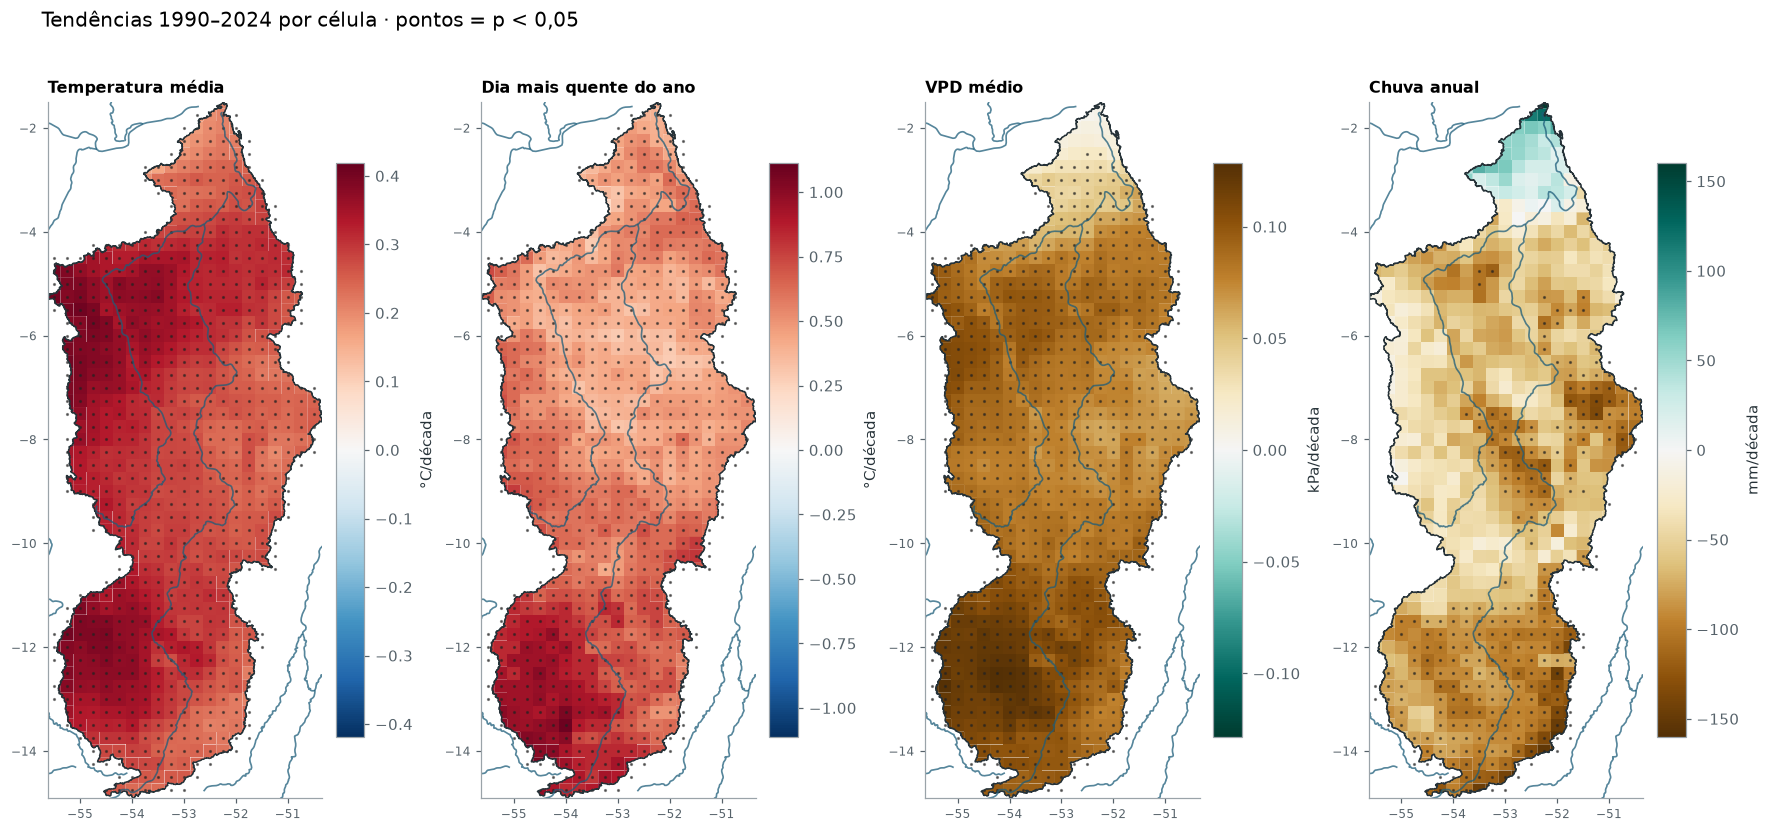

In [14]:
annual_cells = SUMMARY[['cell_t2m', 'cell_vpd', 'cell_precip']].groupby('month.year')
annual_cells = xr.merge([
    annual_cells.mean()[['cell_t2m', 'cell_vpd']],
    annual_cells.sum(min_count=12)[['cell_precip']],
    SUMMARY[['hottest_day']],
])

def trend_map(field):
    stacked = field.stack(cell=('latitude', 'longitude'))
    years = stacked.year.values.astype(float)
    out = np.array([theil_sen(stacked[:, i].values, years) for i in range(stacked.sizes['cell'])])
    slope = stacked.isel(year=0).copy(data=out[:, 0]).unstack('cell')
    p = stacked.isel(year=0).copy(data=out[:, 1]).unstack('cell')
    return slope.where(INSIDE), (p < .05) & INSIDE

maps = [('cell_t2m', 'Temperatura média', '°C/década', 'RdBu_r'),
        ('hottest_day', 'Dia mais quente do ano', '°C/década', 'RdBu_r'),
        ('cell_vpd', 'VPD médio', 'kPa/década', 'BrBG_r'),
        ('cell_precip', 'Chuva anual', 'mm/década', 'BrBG')]
fig, axes = plt.subplots(1 if tall else 2, 4 if tall else 2,
                         figsize=(16, 7.8) if tall else (12, 11), layout='constrained')
for ax, (var, title, label, cmap) in zip(np.ravel(axes), maps):
    slope, significant = trend_map(annual_cells[var])
    limit = float(np.nanmax(np.abs(slope)))
    map_cells(ax, CELLS, slope, cmap, label, outline=outline,
              norm=TwoSlopeNorm(0, -limit, limit), stipple=significant, lines=rivers)
    ax.set_title(title, fontsize=10.5)
fig.suptitle('Tendências 1990–2024 por célula · pontos = p < 0,05', fontsize=13, x=.02, ha='left')
save(fig, FIGURES, '11_mapas_tendencia')
plt.show()

## 🔥 9. Anomalias mês a mês e extremos

Cada quadrado é um mês de um ano. Vermelho = mais quente (ou mais seco, no painel de chuva)
que a normal daquele mês. Procure os episódios amplamente documentados na Amazônia: os
El Niño fortes de **1997–98, 2015–16 e 2023–24** e as secas de **2005 e 2010**.

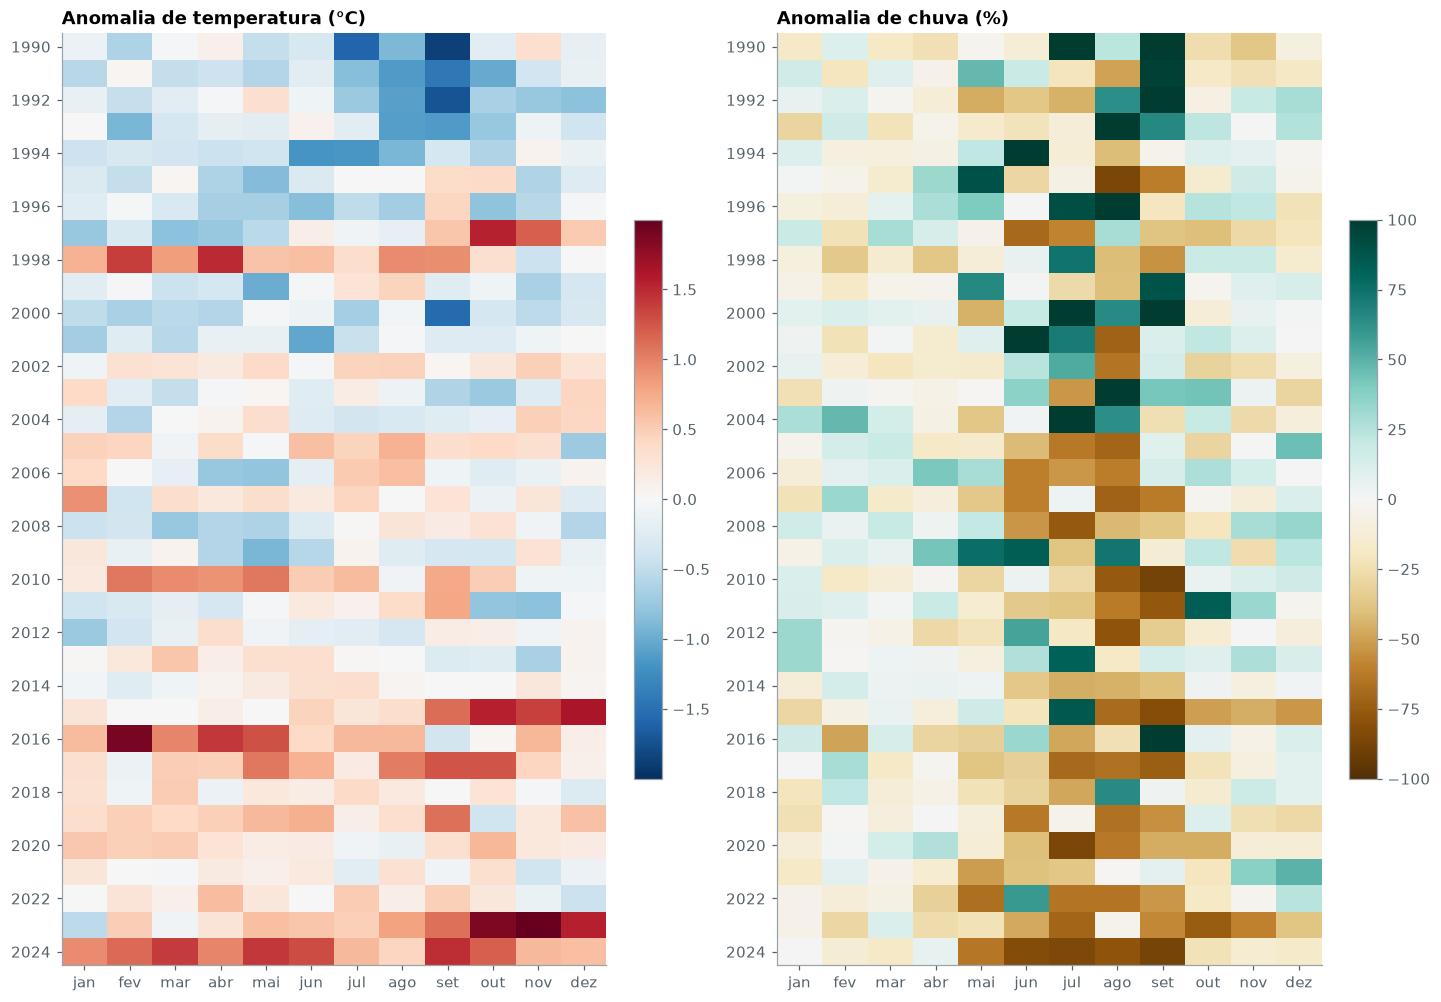

In [15]:
months_all = DAILY.resample('MS').agg(agg)
month_normal = months_all.loc[BASE[0]:BASE[1]].groupby(lambda d: d.month).mean()
t_anom = months_all.t2m - month_normal.t2m.reindex(months_all.index.month).values
r_anom = 100 * (months_all.precip / month_normal.precip.reindex(months_all.index.month).values - 1)
grid = lambda s: s.groupby([s.index.year, s.index.month]).first().unstack()
fig, axes = plt.subplots(1, 2, figsize=(13, 9), layout='constrained')
for ax, data, cmap, label, lim in [
        (axes[0], grid(t_anom), 'RdBu_r', 'Anomalia de temperatura (°C)', float(np.abs(t_anom).max())),
        (axes[1], grid(r_anom), 'BrBG', 'Anomalia de chuva (%)', 100)]:
    im = ax.imshow(data, aspect='auto', cmap=cmap, norm=TwoSlopeNorm(0, -lim, lim))
    ax.set(xticks=range(12), xticklabels=MONTHS, yticks=range(0, len(data), 2),
           yticklabels=data.index[::2], title=label)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=.6)
save(fig, FIGURES, '12_anomalias_mensais')
plt.show()

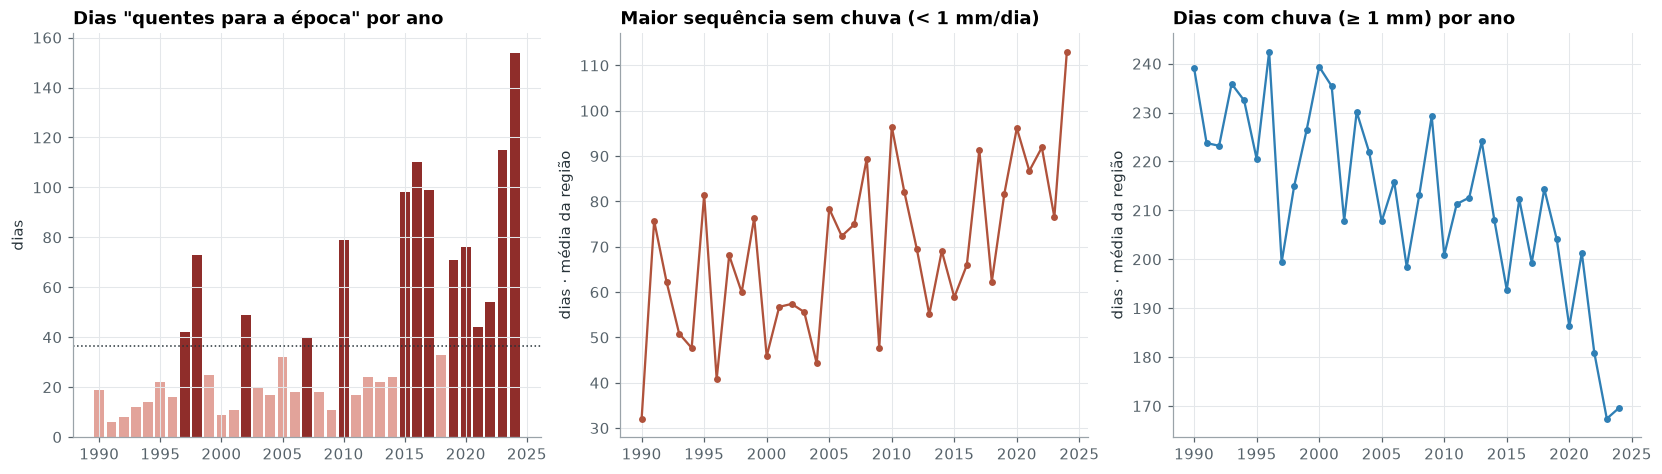

"Quente para a época" = máxima regional acima do 90º percentil das anomalias de 1991–2020 (por construção, ~36,5 dias por ano na normal, linha pontilhada). A sequência seca é calculada em cada célula e depois promediada; sequências que atravessam o réveillon são cortadas na virada do ano.

,máxima regional (°C)
time,
05/09/2024,37.48
21/10/2023,37.36
20/10/2023,37.10
17/09/2024,36.97
23/09/2011,36.92
05/10/2015,36.86
22/10/2015,36.86
14/11/2023,36.86


In [16]:
t_daily, _ = anomalies(DAILY.tmax, BASE)
threshold = t_daily.loc[BASE[0]:BASE[1]].quantile(.9)
hot_days = (t_daily > threshold).groupby(t_daily.index.year).sum()
rain_days = (SUMMARY.rain_days * SUMMARY.weight_km2).sum(('latitude', 'longitude')).values \
    / float(SUMMARY.weight_km2.sum())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), layout='constrained')
axes[0].bar(hot_days.index, hot_days, color=[COLORS['tmax'] if v > 36.5 else '#e2a39a' for v in hot_days])
axes[0].axhline(36.5, color=COLORS['ink'], ls=':', lw=1)
axes[0].set(title='Dias "quentes para a época" por ano', ylabel='dias')
axes[1].plot(annual.index, annual.dry_spell, 'o-', color='#b0523b', ms=3.5)
axes[1].set(title='Maior sequência sem chuva (< 1 mm/dia)', ylabel='dias · média da região')
axes[2].plot(annual.index, rain_days, 'o-', color=COLORS['precip'], ms=3.5)
axes[2].set(title='Dias com chuva (≥ 1 mm) por ano', ylabel='dias · média da região')
save(fig, FIGURES, '13_extremos')
plt.show()
top = DAILY.tmax.nlargest(8).rename('máxima regional (°C)').to_frame()
top.index = top.index.strftime('%d/%m/%Y')
show_md((
    '"Quente para a época" = máxima regional acima do 90º percentil das anomalias de 1991–2020 '
    '(por construção, ~36,5 dias por ano na normal, linha pontilhada). A sequência seca é '
    'calculada em cada célula e depois promediada; sequências que atravessam o réveillon '
    'são cortadas na virada do ano.'))
display(top.round(2))

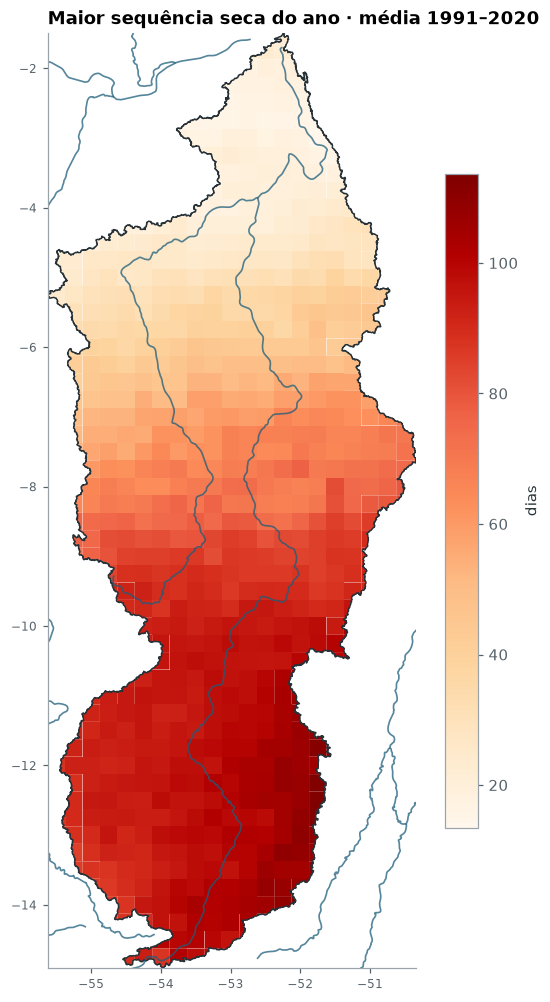

In [17]:
mean_spell = SUMMARY.longest_dry_spell.sel(year=slice(1991, 2020)).mean('year').where(INSIDE)
fig, ax = plt.subplots(figsize=(6.5, 9) if tall else (8, 6), layout='constrained')
map_cells(ax, CELLS, mean_spell, 'OrRd', 'dias', outline=outline, lines=rivers)
ax.set_title('Maior sequência seca do ano · média 1991–2020')
save(fig, FIGURES, '14_mapa_sequencia_seca')
plt.show()

## 🧪 10. Arquivo 1990–2000 × janela científica 2001–2024

A análise principal do TCC usa **2001–2024**; os onze anos anteriores são um arquivo de apoio
para testar a sensibilidade à climatologia e às condições antecedentes (decisão D-006). Aqui
comparamos o ano típico de cada período. Diferenças não são, por si só, efeito de
perturbação: décadas diferentes têm El Niños, secas e tendências globais diferentes.

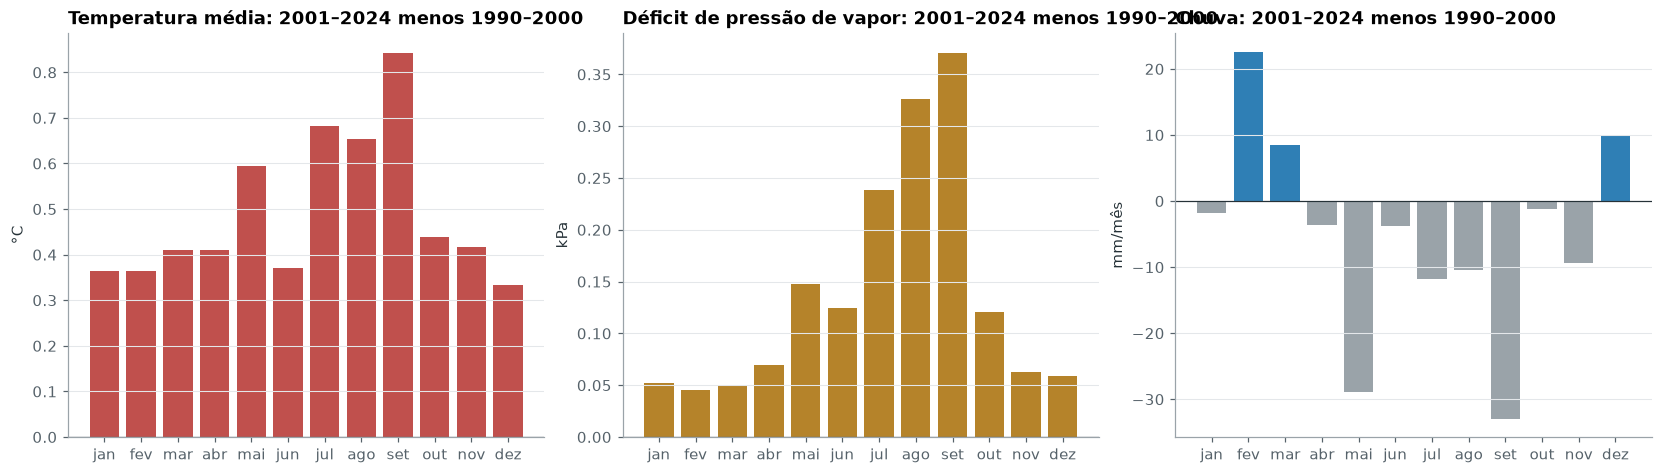

Em média, 2001–2024 foi **+0,49 °C** e teve **-63 mm/ano** em relação a 1990–2000; VPD **+0,139 kPa**.

In [18]:
early = DAILY.loc['1990':'2000'].resample('MS').agg(agg)
late = DAILY.loc[SCIENCE[0]:SCIENCE[1]].resample('MS').agg(agg)
cycle = lambda frame: frame.groupby(frame.index.month).mean()
diff = cycle(late) - cycle(early)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), layout='constrained')
for ax, (var, unit) in zip(axes, [('t2m', '°C'), ('vpd', 'kPa'), ('precip', 'mm/mês')]):
    values = diff[var].values
    ax.bar(MONTHS, values, color=np.where(values > 0, COLORS[var], '#9aa3a9'))
    ax.axhline(0, color=COLORS['ink'], lw=.8)
    ax.set(title=f'{LABELS[var].split(" (")[0]}: 2001–2024 menos 1990–2000', ylabel=unit)
    ax.grid(axis='x', visible=False)
save(fig, FIGURES, '15_arquivo_vs_janela')
plt.show()
show_md((
    f'Em média, 2001–2024 foi **{diff.t2m.mean():+.2f} °C** e teve **{diff.precip.sum():+.0f} mm/ano** '
    f'em relação a 1990–2000; VPD **{diff.vpd.mean():+.3f} kPa**.'))

## 🌀 11. Uma ponte para o caos: o espaço de fases

A Teoria do Caos olha para um sistema pela sua **trajetória no espaço de fases**. Com uma
única série medida, o teorema de Takens diz que podemos reconstruir uma imagem equivalente
desse espaço usando **cópias atrasadas** da própria série: cada ponto é
$(x_t,\; x_{t+\tau},\; x_{t+2\tau})$.

Três passos, com a temperatura média regional de 2001–2024:

1. **Tirar o ciclo anual.** Senão, a trajetória só desenharia o "ano": um laço previsível.
   Ficamos com as anomalias diárias.
2. **Escolher o atraso τ.** Uma regra simples: o primeiro atraso em que a autocorrelação cai
   abaixo de 1/e (cópias que já trazem informação "nova").
3. **Comparar com um sistema sem estrutura não linear.** Uma **série substituta** com o mesmo
   espectro (mesma autocorrelação), mas fases embaralhadas: é o que uma dinâmica linear com
   ruído produziria.

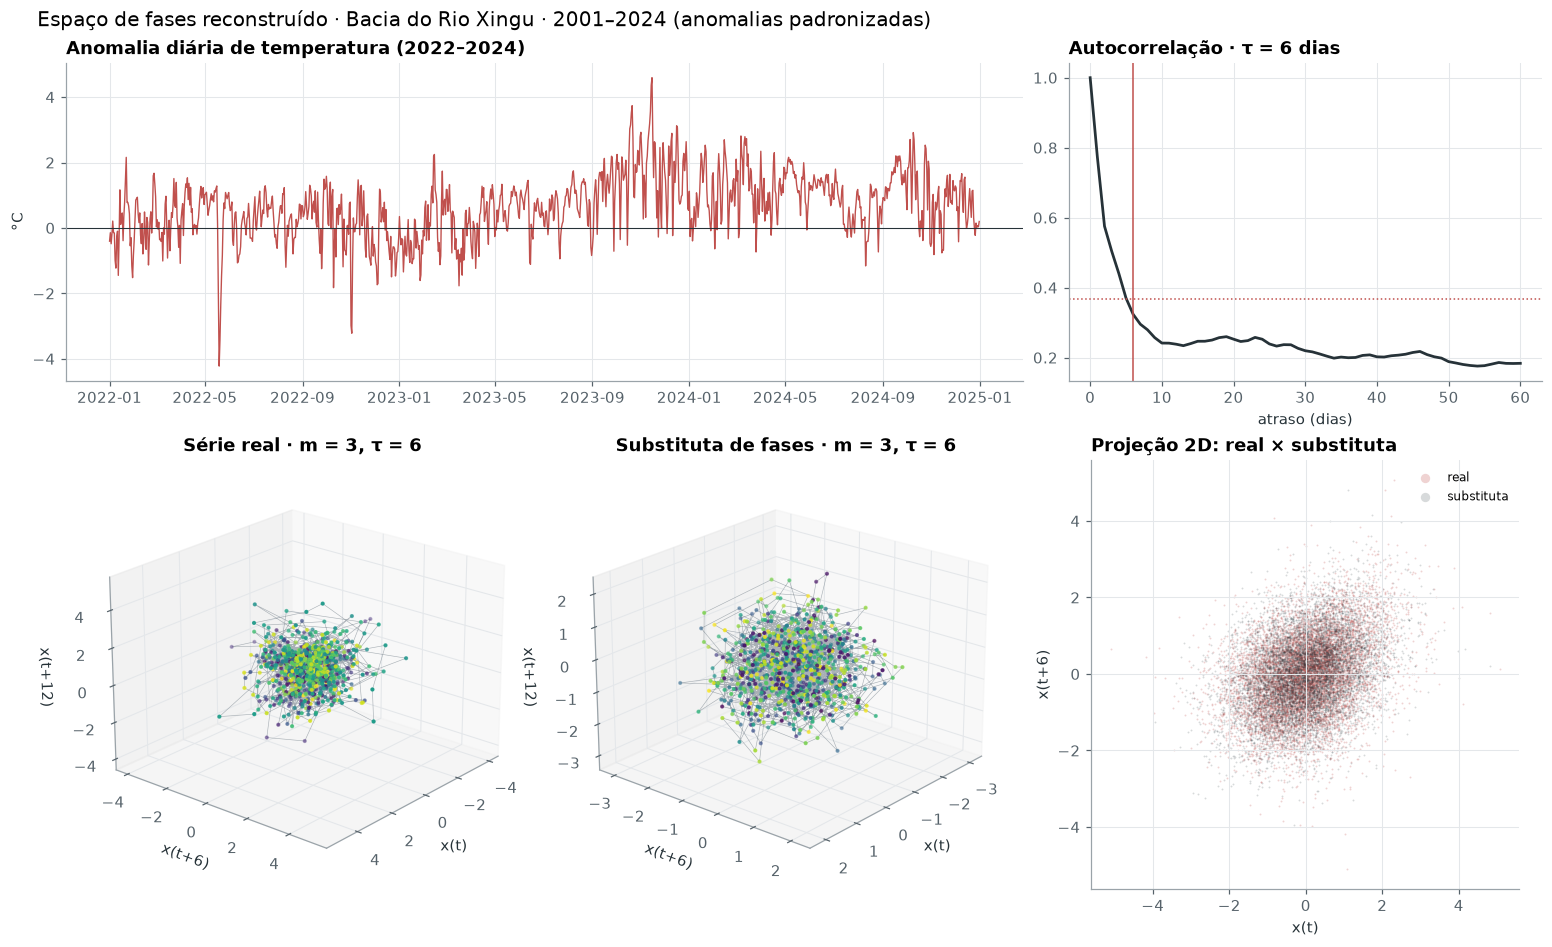

In [19]:
anomaly_daily = anomalies(DAILY.t2m, BASE)[0].loc[SCIENCE[0]:SCIENCE[1]]
x = ((anomaly_daily - anomaly_daily.mean()) / anomaly_daily.std()).to_numpy()
acf = np.array([1.0] + [np.corrcoef(x[:-k], x[k:])[0, 1] for k in range(1, 61)])
tau = int(np.argmax(acf < 1 / np.e))
surrogate = phase_randomized_surrogate(x, np.random.default_rng(42))

fig = plt.figure(figsize=(14, 8.5), layout='constrained')
top = fig.add_gridspec(2, 3, height_ratios=[1, 1.35])
ax = fig.add_subplot(top[0, :2])
last = anomaly_daily.loc['2022':]
ax.plot(last.index, last, color=COLORS['t2m'], lw=.9)
ax.axhline(0, color=COLORS['ink'], lw=.7)
ax.set(title='Anomalia diária de temperatura (2022–2024)', ylabel='°C')
ax = fig.add_subplot(top[0, 2])
ax.plot(acf, color=COLORS['ink'], lw=1.8)
ax.axhline(1 / np.e, color=COLORS['t2m'], ls=':', lw=1)
ax.axvline(tau, color=COLORS['t2m'], lw=1)
ax.set(title=f'Autocorrelação · τ = {tau} dias', xlabel='atraso (dias)')
for col, (series, name) in enumerate([(x, 'Série real'), (surrogate, 'Substituta de fases')]):
    ax = fig.add_subplot(top[1, col], projection='3d')
    cloud = delay_embedding(series, 3, tau)
    ax.plot(*cloud[-900:].T, color=COLORS['muted'], lw=.4, alpha=.7)
    ax.scatter(*cloud[-900:].T, c=np.arange(900), cmap='viridis', s=3)
    ax.set(title=f'{name} · m = 3, τ = {tau}', xlabel='x(t)', ylabel=f'x(t+{tau})',
           zlabel=f'x(t+{2 * tau})')
    ax.view_init(22, 40)
ax = fig.add_subplot(top[1, 2])
real, fake = delay_embedding(x, 2, tau), delay_embedding(surrogate, 2, tau)
ax.scatter(*real.T, s=1.5, color=COLORS['t2m'], alpha=.25, label='real', lw=0)
ax.scatter(*fake.T, s=1.5, color=COLORS['ink'], alpha=.18, label='substituta', lw=0)
ax.set(title='Projeção 2D: real × substituta', xlabel='x(t)', ylabel=f'x(t+{tau})', aspect='equal')
ax.legend(markerscale=5, fontsize=8)
fig.suptitle(f'Espaço de fases reconstruído · {REGION} · 2001–2024 (anomalias padronizadas)',
             fontsize=13, x=.02, ha='left')
save(fig, FIGURES, '17_espaco_de_fases')
plt.show()

> 🌀 **O que (não) concluir.** As nuvens real e substituta parecem muito semelhantes: **a olho
> nu, não dá para dizer se há estrutura não linear**. É exatamente por isso que o projeto usa
> testes quantitativos (dimensão de imersão por falsos vizinhos, expoente de Lyapunov,
> gráficos de recorrência), sempre comparados com muitas substitutas e validados antes em
> sistemas sintéticos conhecidos (caderno do laboratório). Este gráfico é o ponto de partida,
> não um resultado. Note também que a média regional suaviza a série: descritores de
> células ou de sub-regiões podem se comportar de forma diferente.

## ✅ 12. Em resumo

In [20]:
t_trend = trends.loc['Temperatura média (°C)']
v_trend = trends.loc['VPD médio (kPa)']
show_md(('\n'.join([
    f'- **{REGION}** · {int(INSIDE.sum())} células ERA5 · {float(SUMMARY.weight_km2.sum()):,.0f} km² · '
    f'{len(DAILY):,} dias completos de 1990 a 2024.',
    f'- **Ano típico (1991–2020):** {normals.t2m.mean():.1f} °C de média, {annual_rain.mean():,.0f} mm '
    f'de chuva, meses secos: {", ".join(dry) if dry else "nenhum"}.',
    f'- **Temperatura:** {t_trend.iloc[0]:+.2f} °C/década em 1990–2024 '
    f'({t_trend.iloc[2]:+.2f} °C/década em 2001–2024); ano mais quente: {anomaly.idxmax()}.',
    f'- **VPD:** {v_trend.iloc[0]:+.3f} kPa/década em 1990–2024.',
    f'- **Dia mais quente da série:** {DAILY.tmax.max():.1f} °C (média regional das máximas) '
    f'em {DAILY.tmax.idxmax():%d/%m/%Y}.',
    f'- **Espaço de fases:** τ = {tau} dias pela autocorrelação; sem distinção visual '
    'em relação à substituta linear, como esperado antes dos testes formais.',
])))

- **Bacia do Rio Xingu** · 779 células ERA5 · 508.627 km² · 12.784 dias completos de 1990 a 2024.
- **Ano típico (1991–2020):** 25,6 °C de média, 1.891 mm de chuva, meses secos: jun, jul, ago, set.
- **Temperatura:** +0,29 °C/década em 1990–2024 (+0,29 °C/década em 2001–2024); ano mais quente: 2024.
- **VPD:** +0,087 kPa/década em 1990–2024.
- **Dia mais quente da série:** 37,5 °C (média regional das máximas) em 05/09/2024.
- **Espaço de fases:** τ = 6 dias pela autocorrelação; sem distinção visual em relação à substituta linear, como esperado antes dos testes formais.

### Cuidados de leitura

- **Reanálise não é estação.** O ERA5 é consistente e completo, mas em regiões com poucas
  observações depende mais do modelo; a cobertura do solo no modelo **não acompanha** o
  desmatamento ano a ano.
- **Precisão do EDH** (~0,05% relativa) é irrelevante para as médias regionais, mas será
  testada para métodos não lineares por célula (D-007).
- **Tendência não é causa.** Nada aqui separa efeitos de perturbação local, variabilidade
  natural (ENSO, Atlântico) e aquecimento global.
- **A média da bacia mistura climas.** Comparações devem usar estratos comparáveis (norte/sul, bioma, relevo), não a bacia inteira.

### Próximos passos

1. Integrar as bases de perturbação (MapBiomas cobertura e fogo, PRODES, DETER), com as
   limitações históricas de cada uma.
2. Classificar células por nível de perturbação **sem olhar** para os descritores dinâmicos.
3. Aplicar os métodos do laboratório (imersão, Lyapunov, recorrência, substitutas) por
   célula e por estrato, com testes de robustez e a comparação EDH × CDS.

### Fontes

[ERA5 horário](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview) ·
[Earth Data Hub](https://earthdatahub.destine.eu/collections/era5/datasets/era5-single-levels-atmosphere) ·
[IBGE — BHB250 e biomas](https://www.ibge.gov.br/geociencias/cartas-e-mapas.html) ·
[FUNAI — geoserviços](https://www.gov.br/funai/pt-br/atuacao/terras-indigenas/geoprocessamento-e-mapas) ·
[ICMBio — dados geoespaciais](https://www.gov.br/icmbio/pt-br/dados-icmbio/dados_geoespaciais) ·
[Natural Earth](https://www.naturalearthdata.com/) ·
[Listras de aquecimento](https://showyourstripes.info/).
Documentação local: `docs/HPC_EDH.md`, `docs/DECISIONS.md` (D-006, D-007), `docs/XINGU.md`.